# 1st Kr NEXT-100 data look

## Run 15502 - compare Kr maps (LT map, 3D, LT - unique)

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [2]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [5]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.kr100ana as krn100
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [6]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Thu Jul 31 16:41:47 2025


## Import Data

In [7]:
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 
path_run =  '15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc1'
#path_run  = '14862/sophronia'
#path_run = '/250107_4bar/data/kdst'
#path_run = '/250203_4bar'


from os import listdir

filenames = listdir(path_data + path_run)
filenames.sort()
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])
filenames = [path_data + path_run + '/' + ifile for ifile in filenames]

number of files : 1
fist files:  ldc1.h5 ldc1.h5


In [8]:
from os import listdir
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 

def getfiles(run_number, 
            version = "v2.3.1/20250512",
            city = "sophronia",
            trigger = 'trigger1',
            ldc = 'ldc1'):
    path_run =  f'{run_number}/hdf5/prod/{version}/sophronia/trigger1/{ldc}/'
    filenames = listdir(path_data + path_run)
    filenames.sort()
    #print('number of files :', len(filenames))
    #print('fist files: ', filenames[0], filenames[-1])
    filenames = [path_data + path_run + '/' + ifile for ifile in filenames]
    return filenames

In [9]:
files = [getfiles(15502, ldc = 'ldc'+str(i+1))[0] for i in range(7)]
files

['/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc1//ldc1.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc2//ldc2.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc3//ldc3.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc4//ldc4.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc5//ldc5.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc6//ldc6.h5',
 '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/ldc7//ldc7.h5']

In [10]:
kdst = load_dsts(files, "DST", "Events")
#kdst = load_dst(filenames[0], "DST", "Events")

In [11]:
kdst.columns

Index(['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h',
       'S1e', 'S1t', 'S2w', 'S2h', 'S2e', 'S2q', 'S2t', 'qmax', 'Nsipm', 'DT',
       'Z', 'Zrms', 'X', 'Y', 'R', 'Phi', 'Xrms', 'Yrms'],
      dtype='object')

## Prepare Data

In [12]:
kdst = krn100.df_extend(kdst)
#kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'dt', 'Zrms': 'dtrms',
#                              'DT' : 'dtime', 'R' : 'r'})

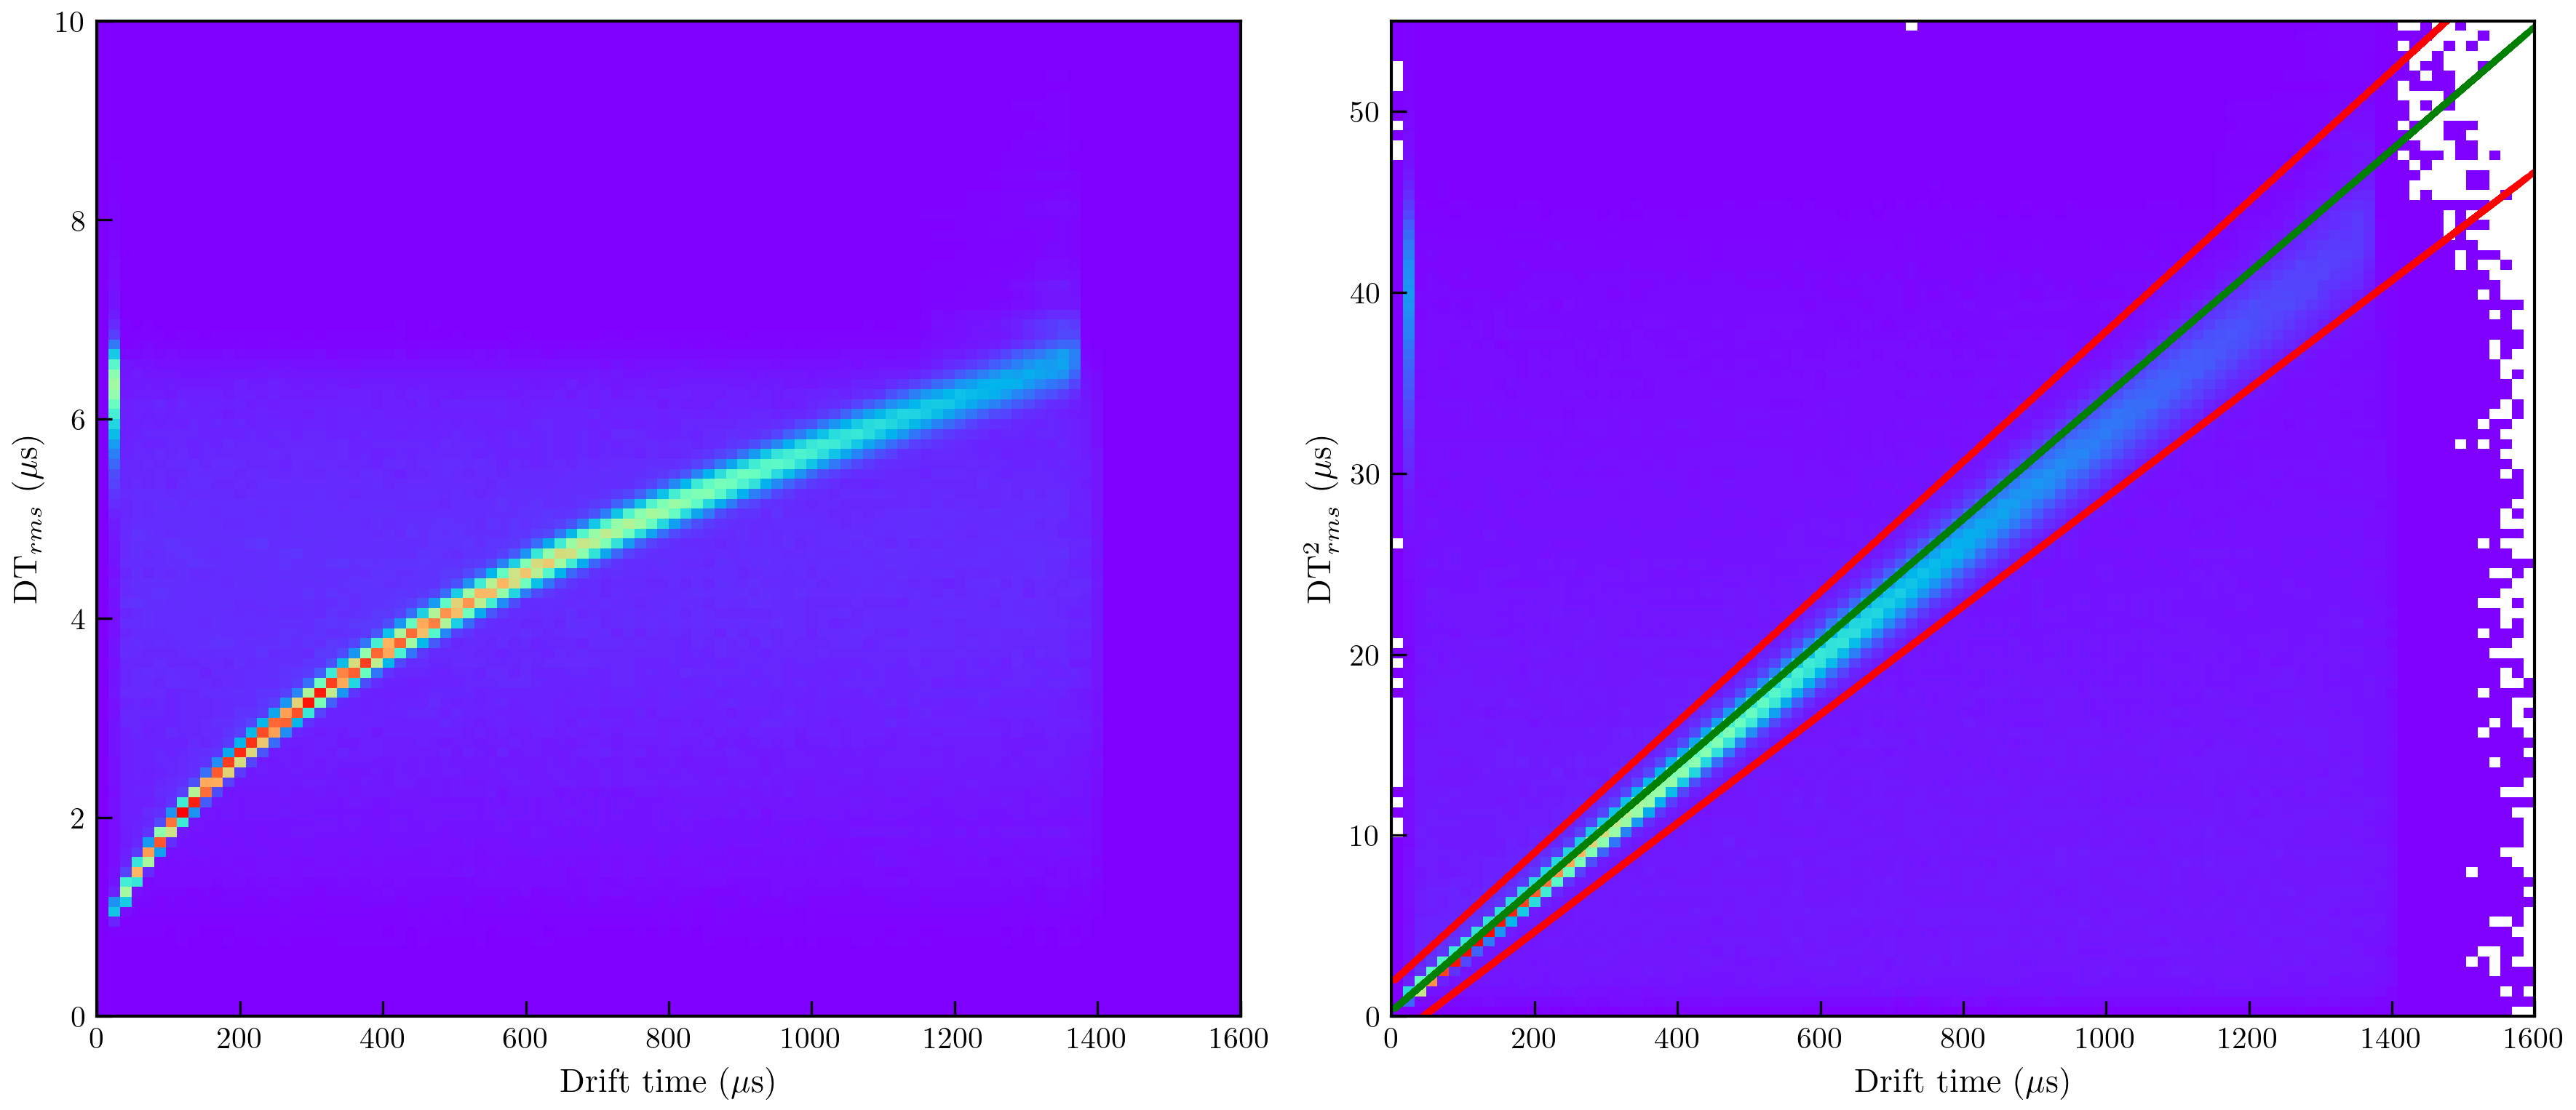

In [13]:
#krn100.monitor_S1S2(kdst)
#krn100.monitor_S2(kdst)
krn100.monitor_S2s_dtime(kdst)
#krn100.monitor_lifetime(kdst)

## Standard selection

In [14]:
kdst_, effs    = krn100.kdst_select(kdst)

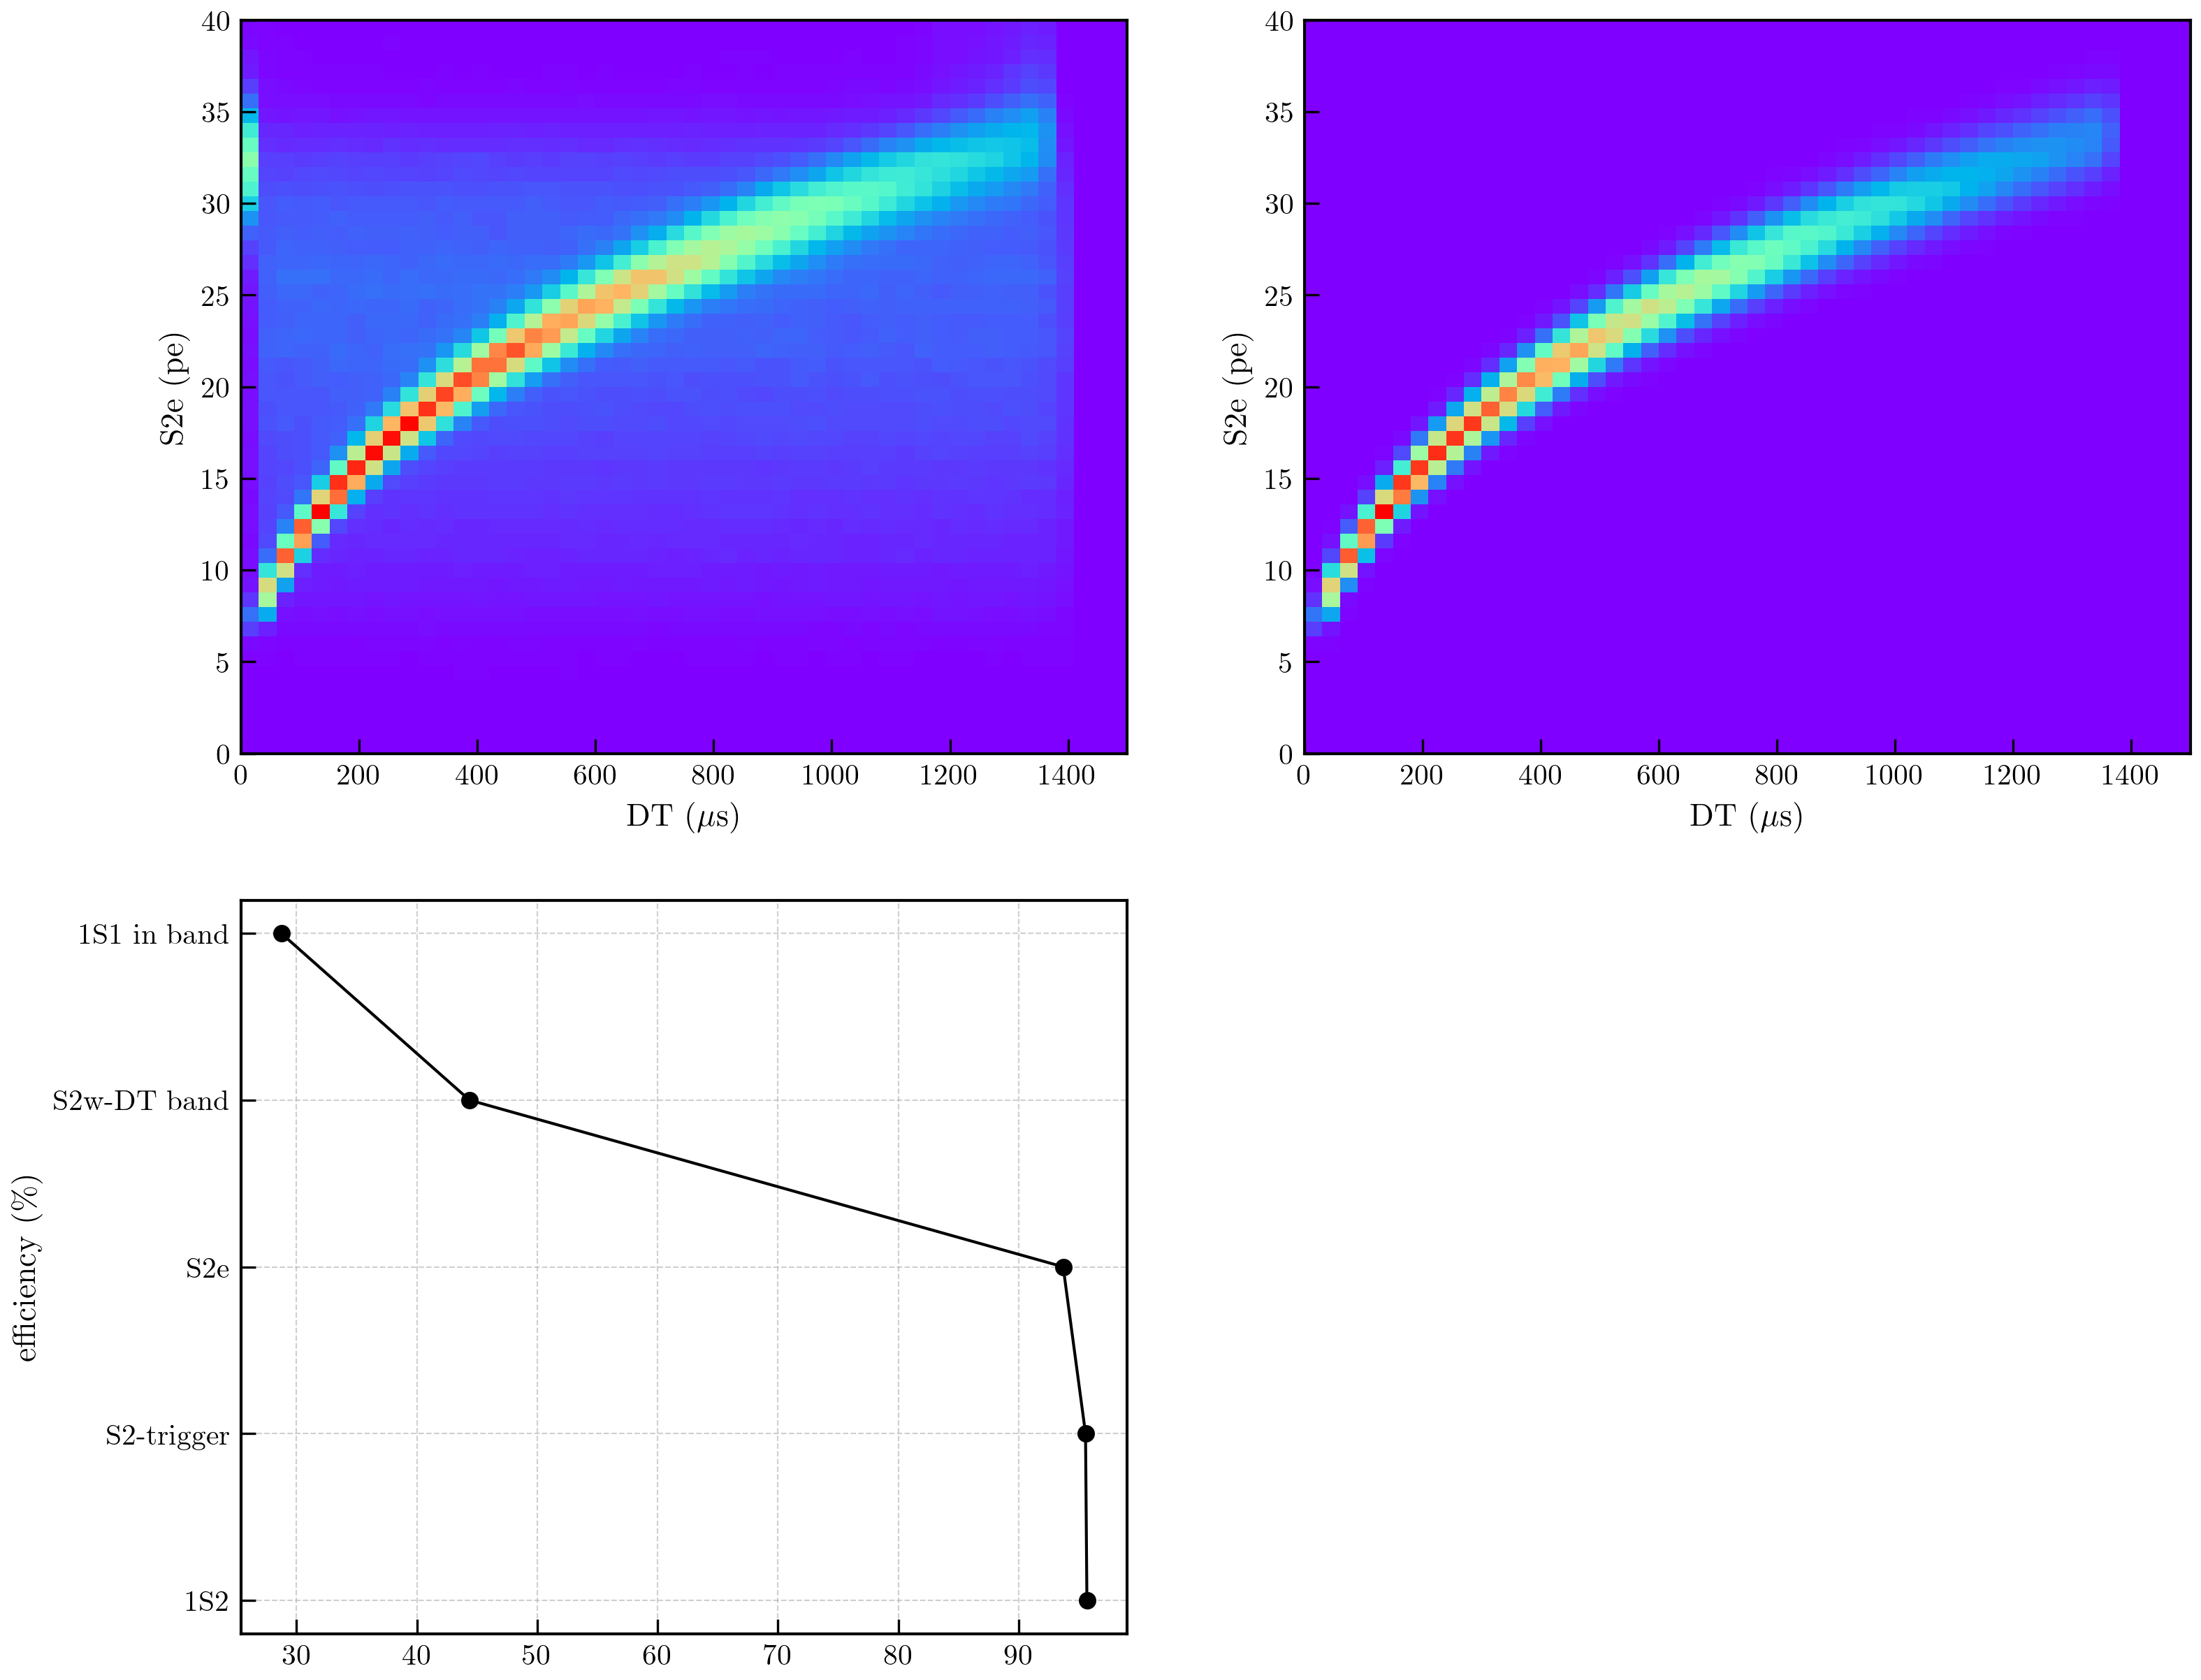

In [15]:
cv = pltext.canvas(4, 2)
cv(3);
names, vals = [x[0] for x in effs], [100.*x[1] for x in effs]
plt.plot(vals, names, marker = "o", color = 'black', lw =1); plt.ylabel("efficiency (\%)")
cv(1); plt.hist2d(kdst.DT, kdst.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');
cv(2); plt.hist2d(kdst_.DT, kdst_.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');

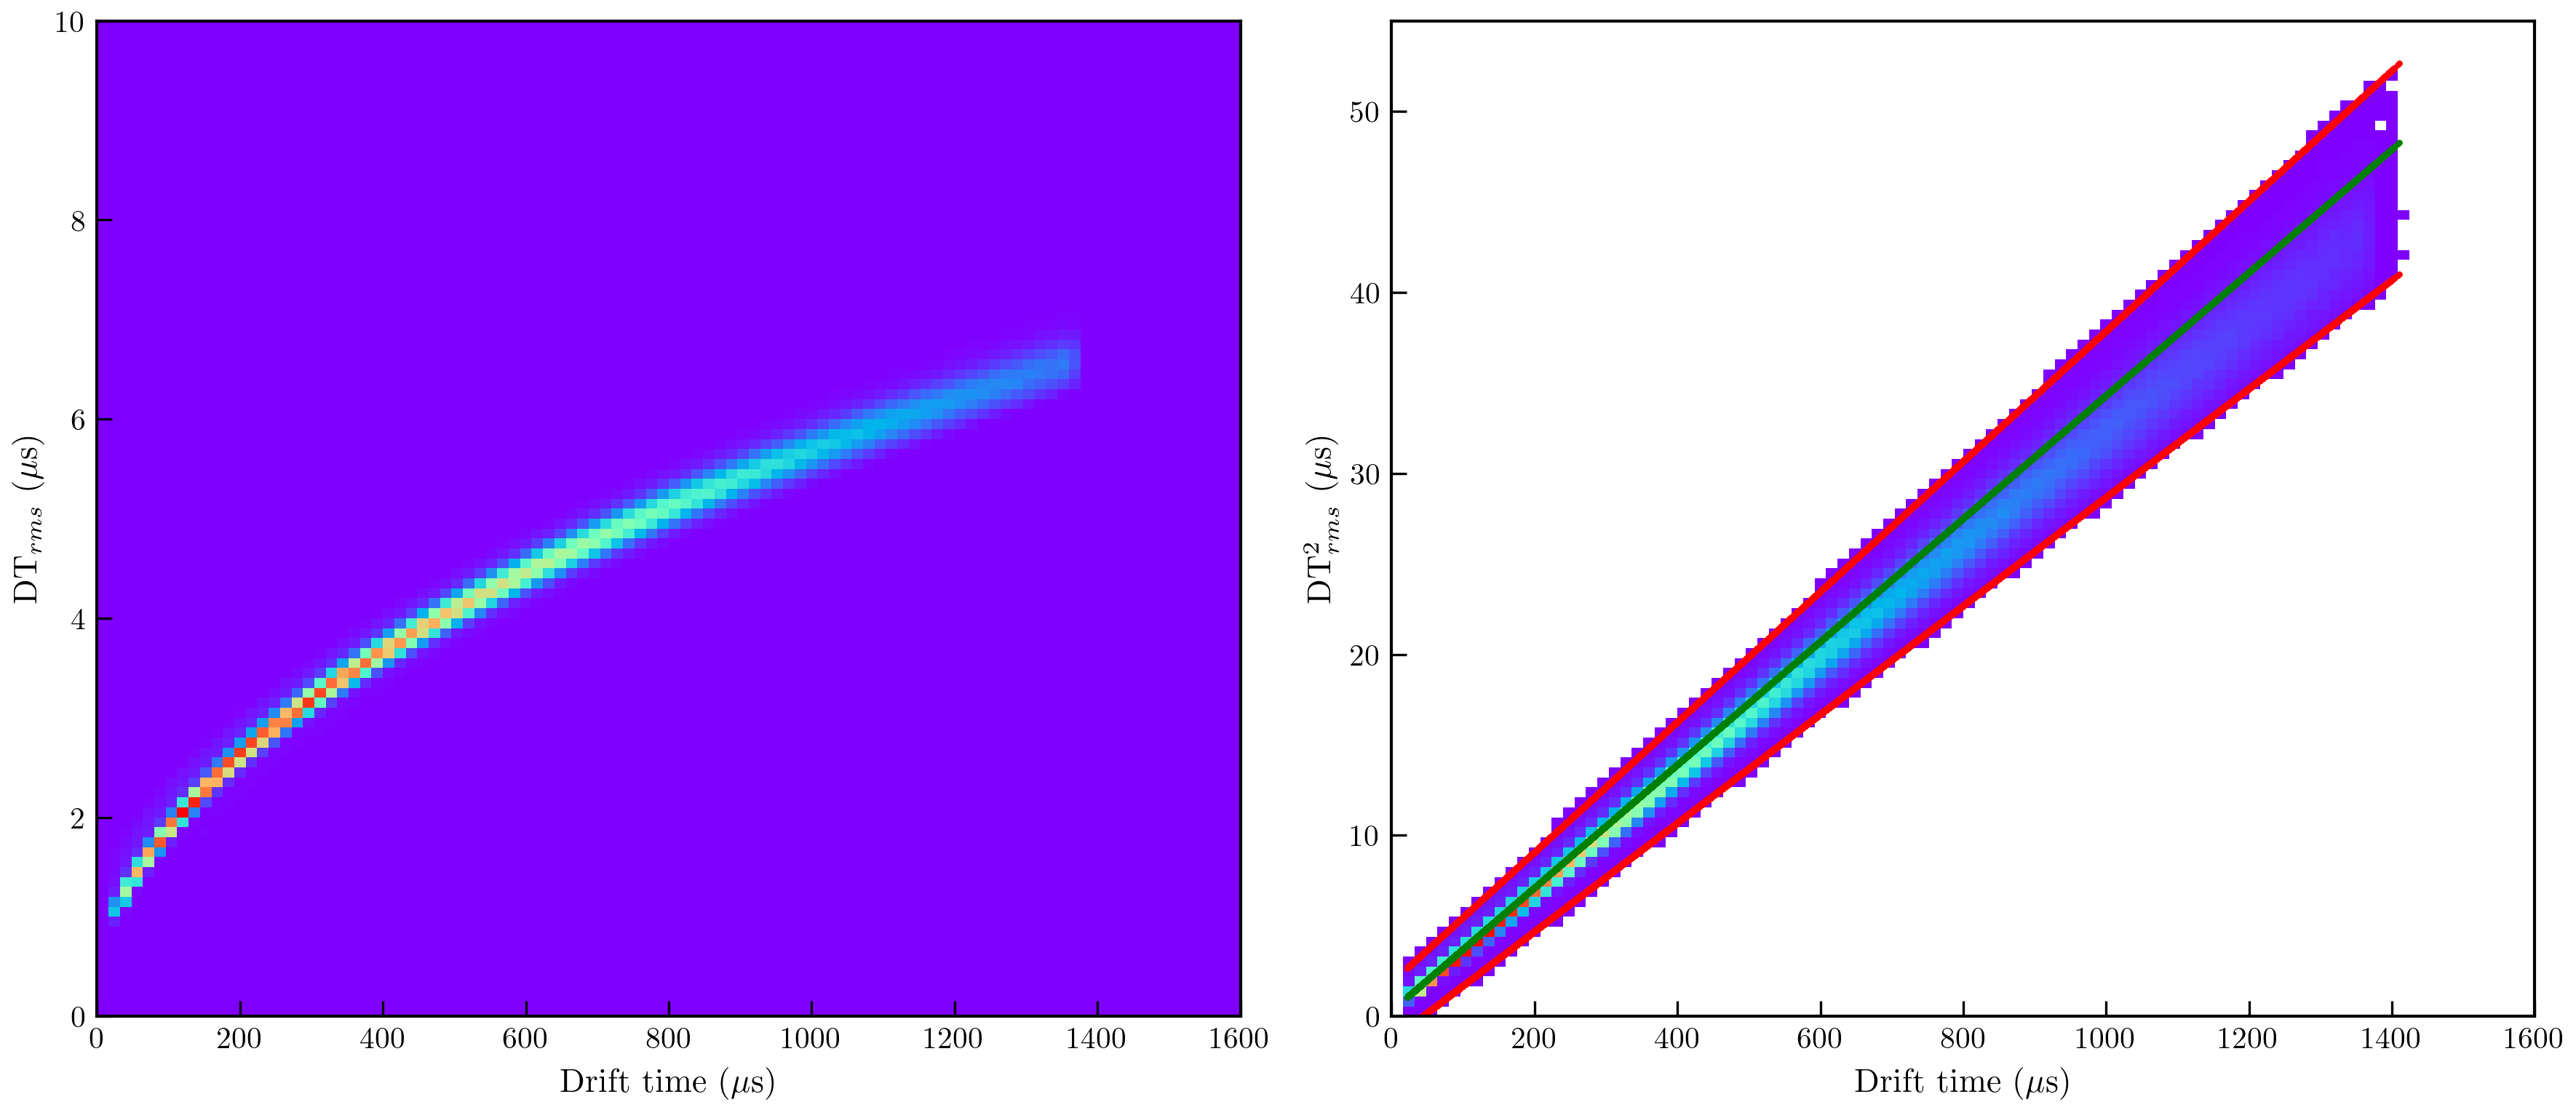

In [16]:
#krn100.monitor_S1S2(kdst_)
#krn100.monitor_S2(kdst_)
krn100.monitor_S2s_dtime(kdst_)
#krn100.monitor_lifetime(kdst_)

## Fidutal selection

In [17]:
df = kdst_
sels = {}
sels['R']        = ut.in_range(df.R  , (0., 500.))
sels['DT']       = ut.in_range(df.DT , (0., 2000.))
sels['S2e']      = ut.in_range(df.S2e, (0e3, 9e3))
sels['fidutial'] = (sels['R']) & (sels['DT']) & (sels['S2e'])

## Clean data : fidutial and residuals

In [18]:
counts_min = 40
pitch      = 5.00
xmin       = -489.825
#xbins      = np.arange(xmin-pitch, -xmin + pitch, pitch)
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  197 , range :  -489.825 ,  490.175


In [19]:
#df     = kdst_
sel    = sels['fidutial']
coors  = df[sel].X, df[sel].Y
energy = df[sel].S2e
dtime  = df[sel].DT

In [20]:
min_sigma = 0.9
dt0       = 0 # compute the map in the EL
sel       = sels['fidutial']
krf, res_1, usel = krtool.krmap_clean((df[sel].X, df[sel].Y), df.DT[sel], df[sel].S2e,
                                       bins = bins, dt0 = dt0, plot = False)

sigma 0.94 done  True  eff 97.85


In [21]:
cdf = df[sel][usel]

## LT unique study

In [22]:
rmax       = 350.
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, 
                                   bins = bins, rmax = rmax, boost = True)

1.0011633895950551 36475.964332320305


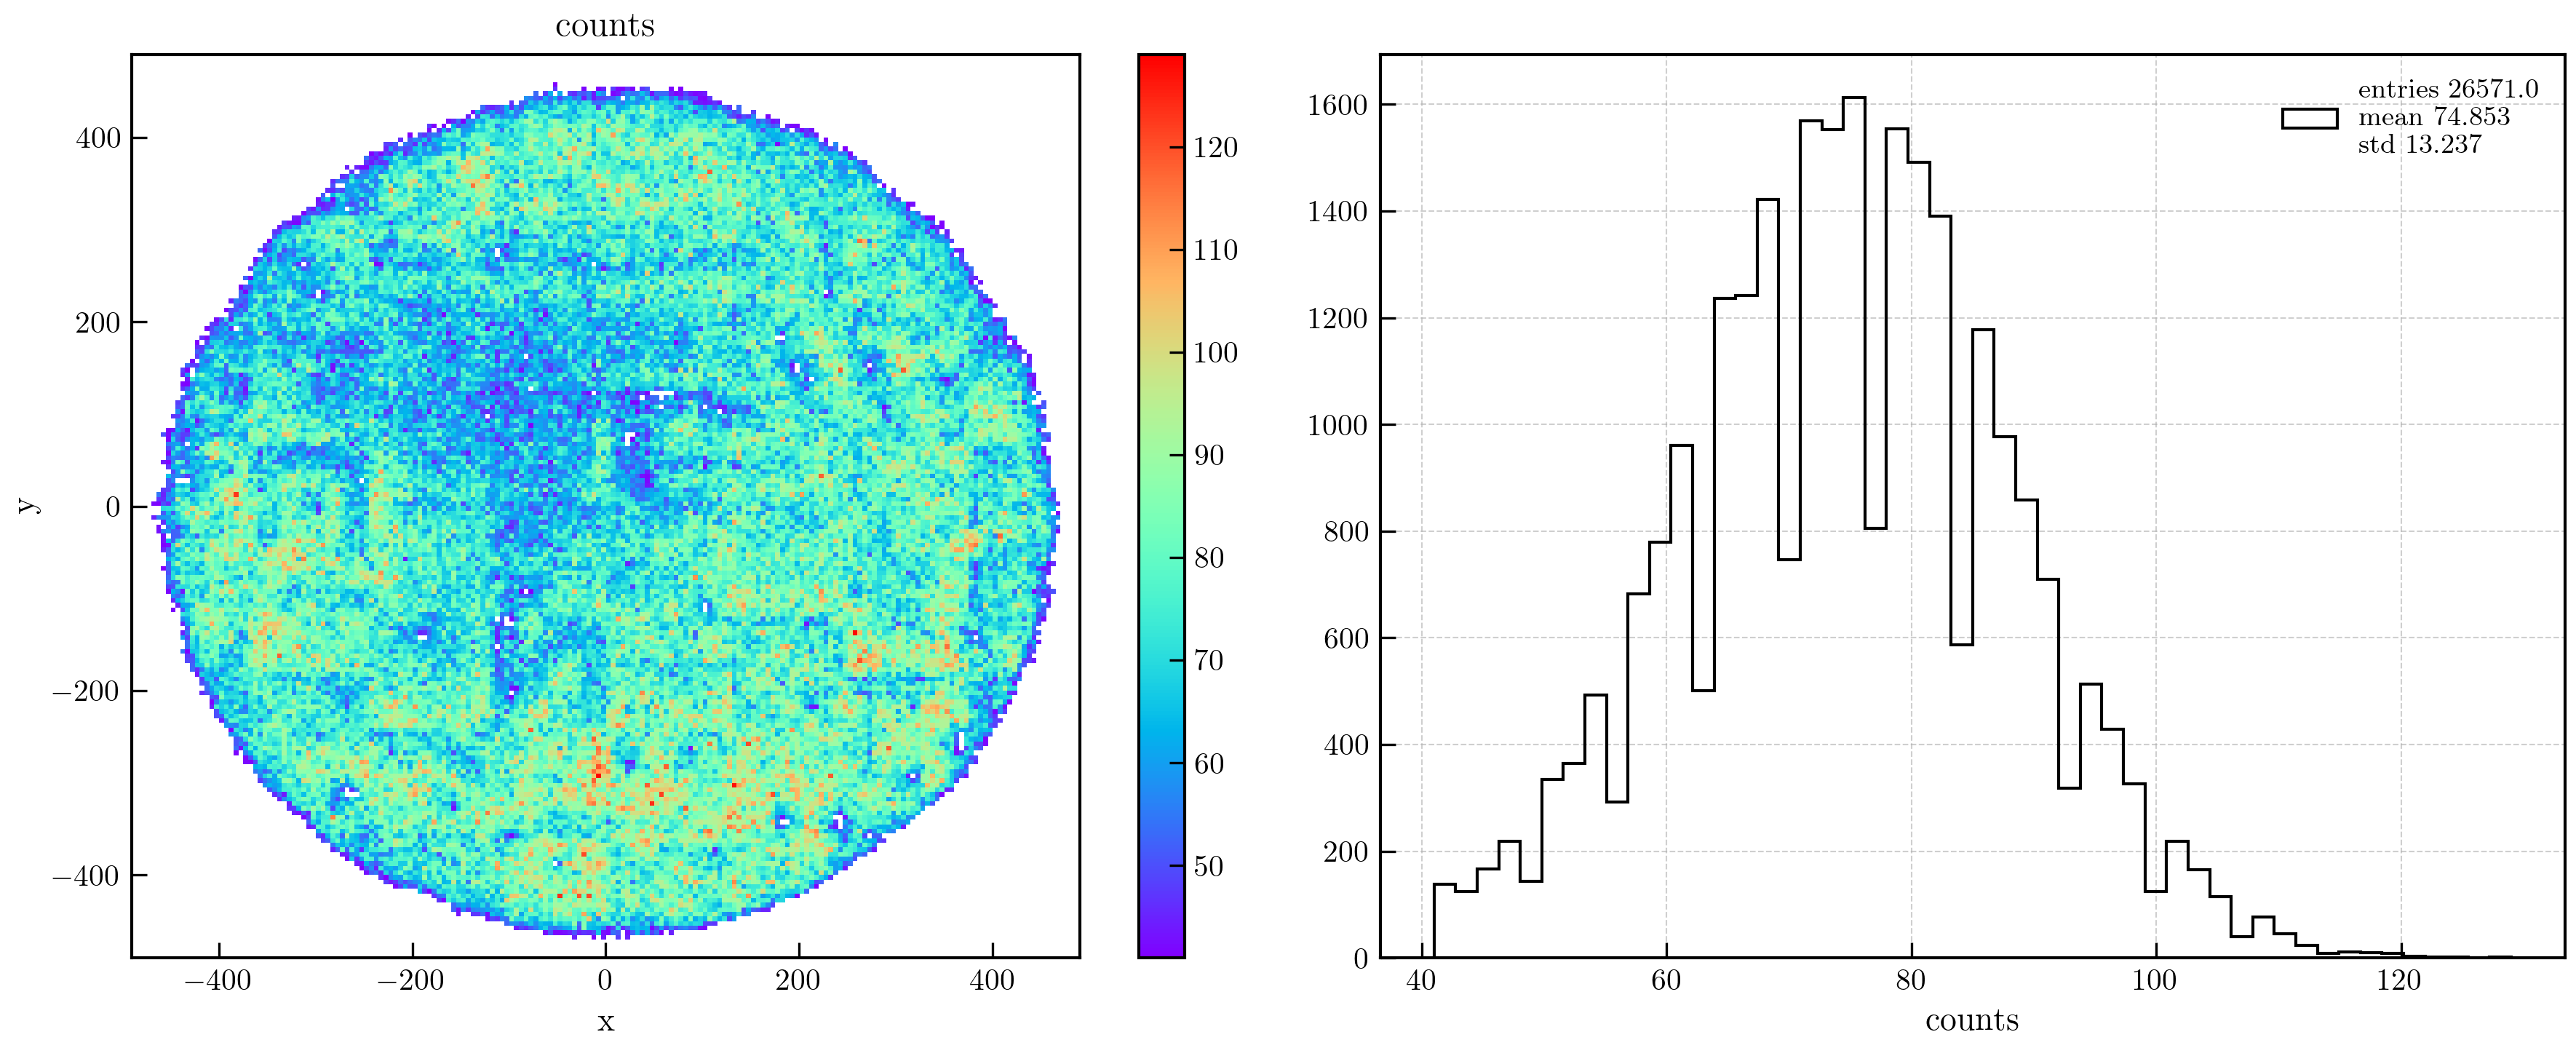

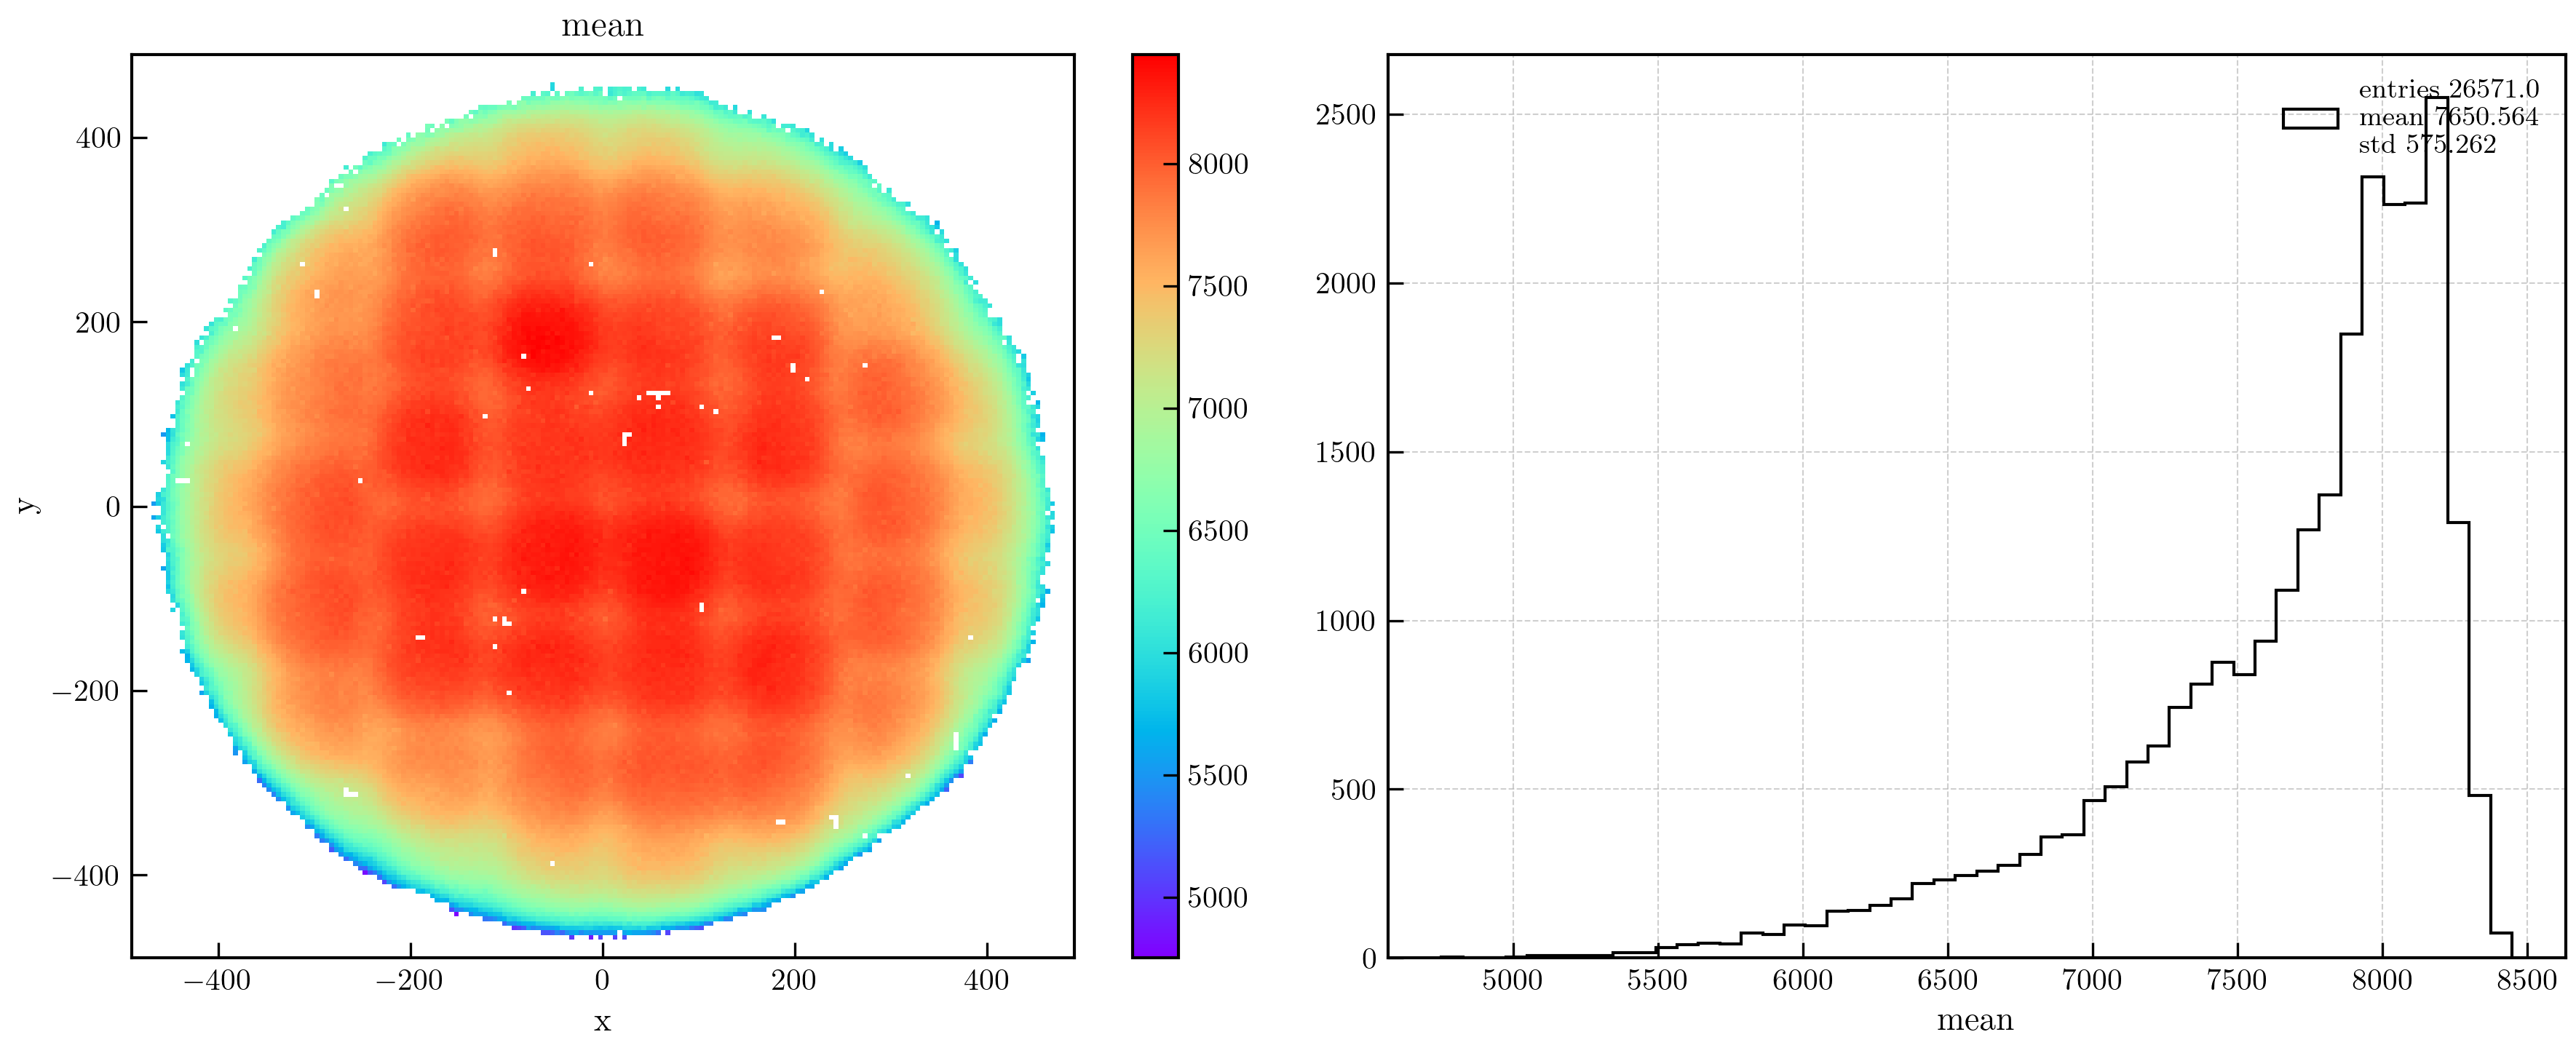

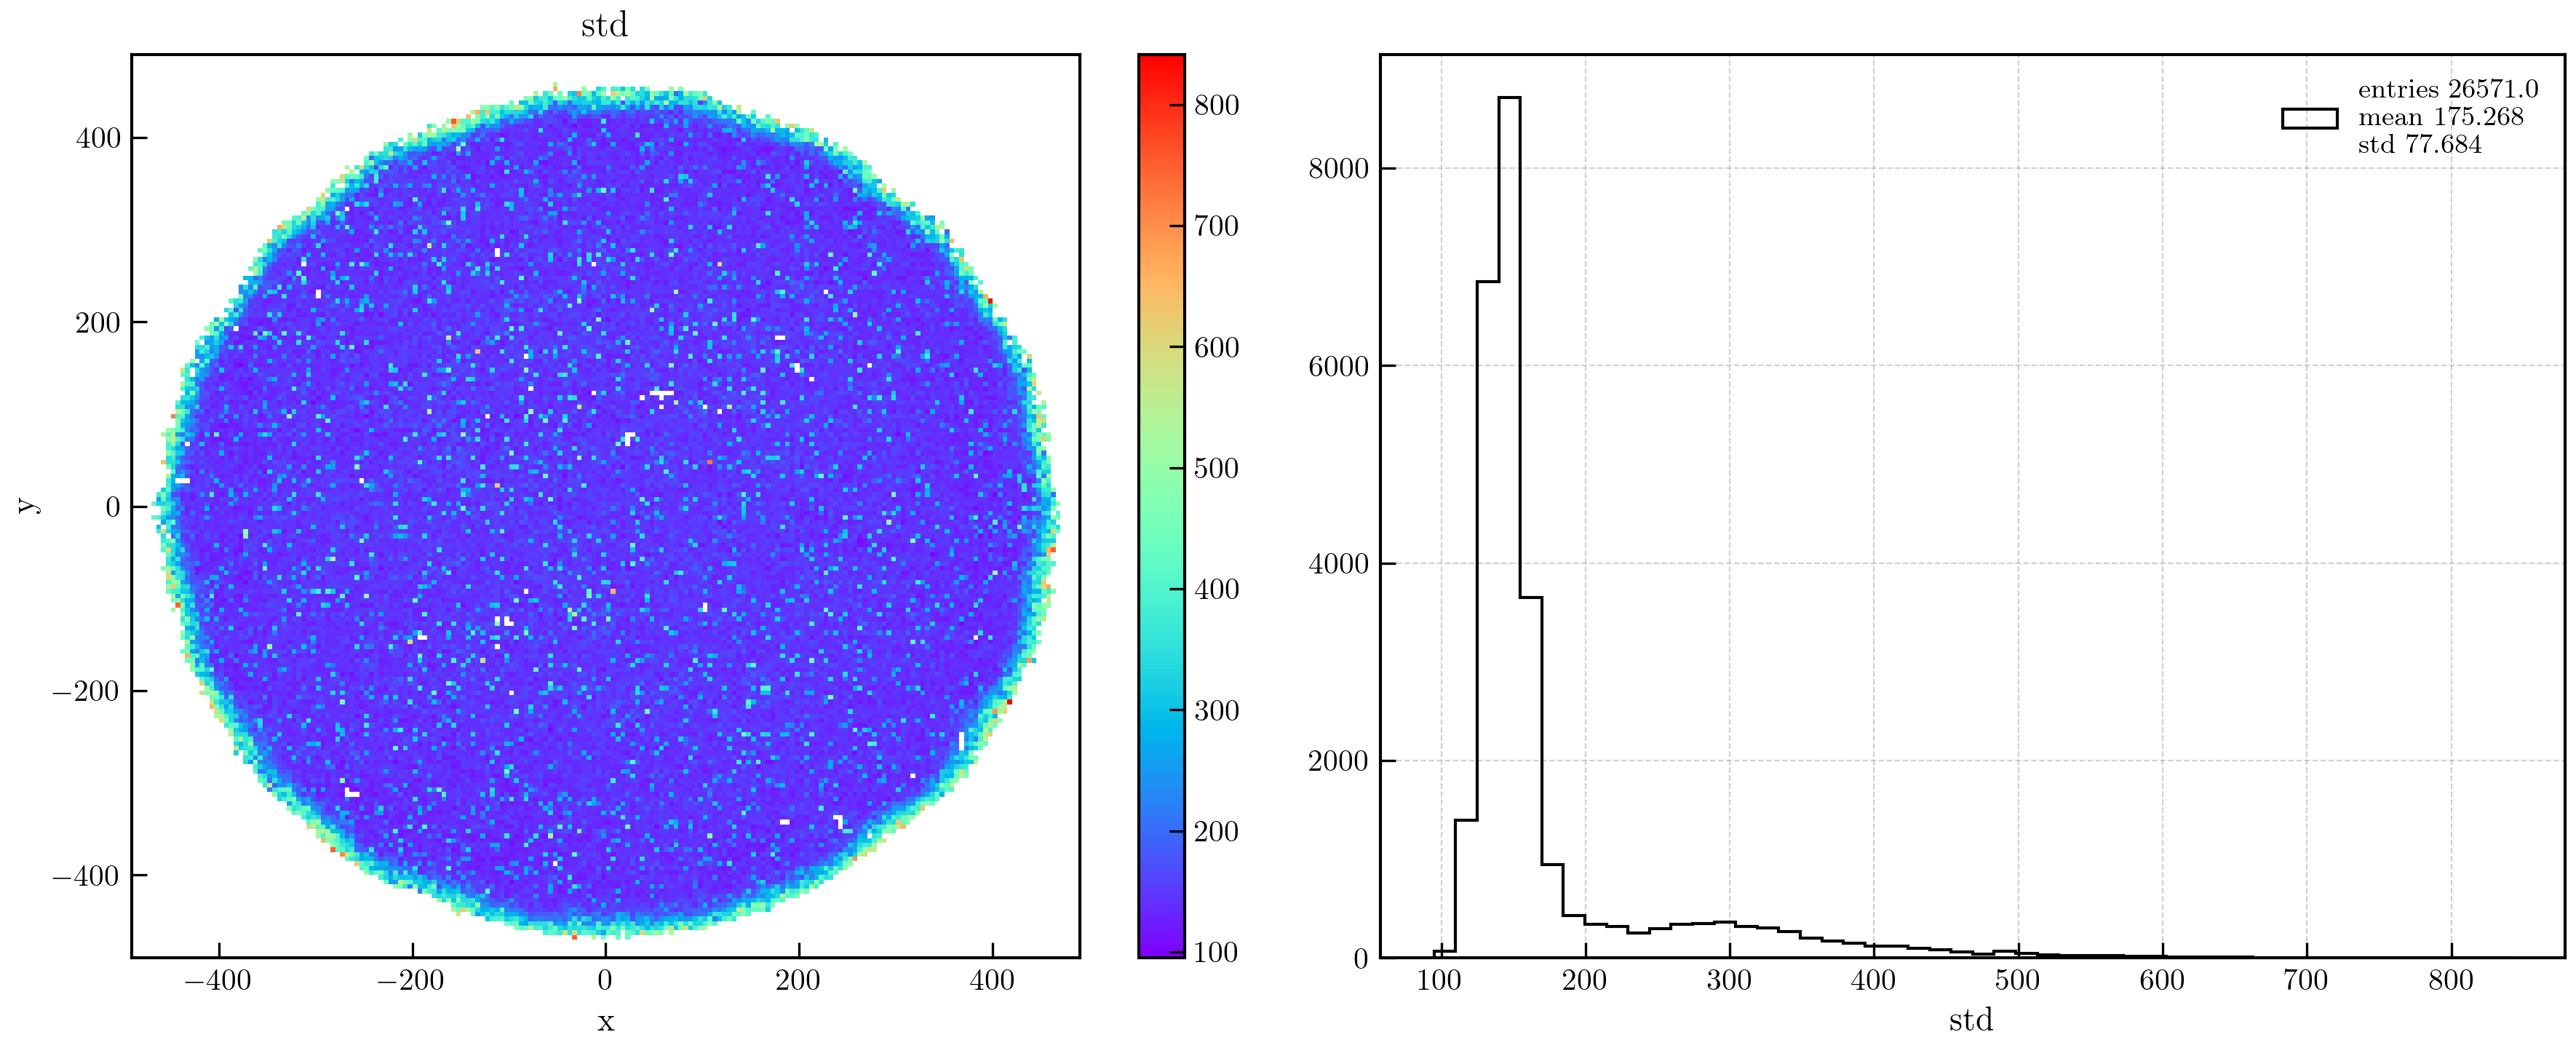

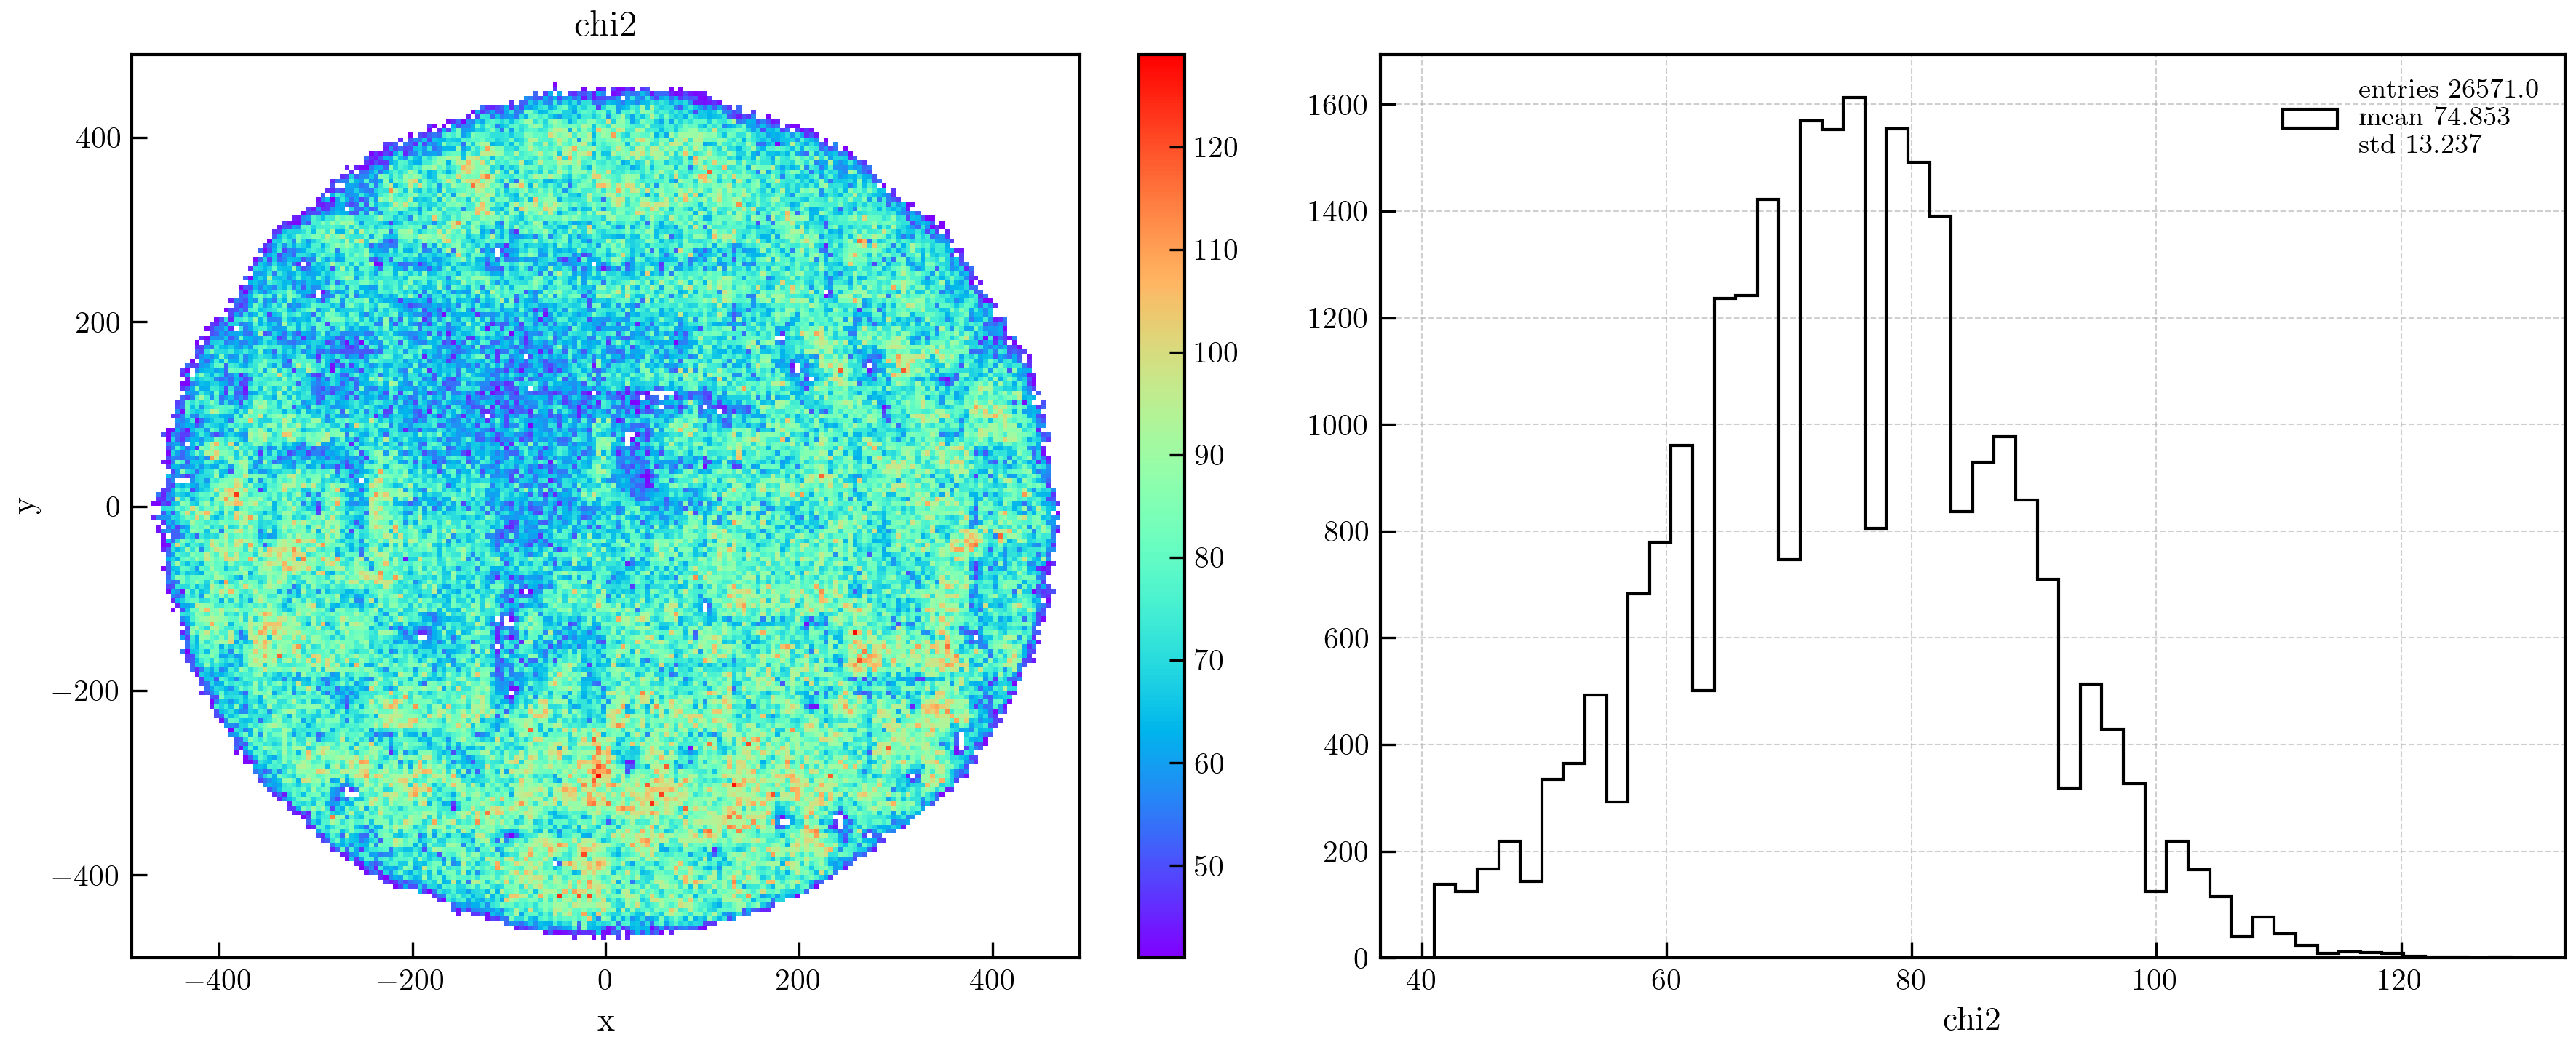

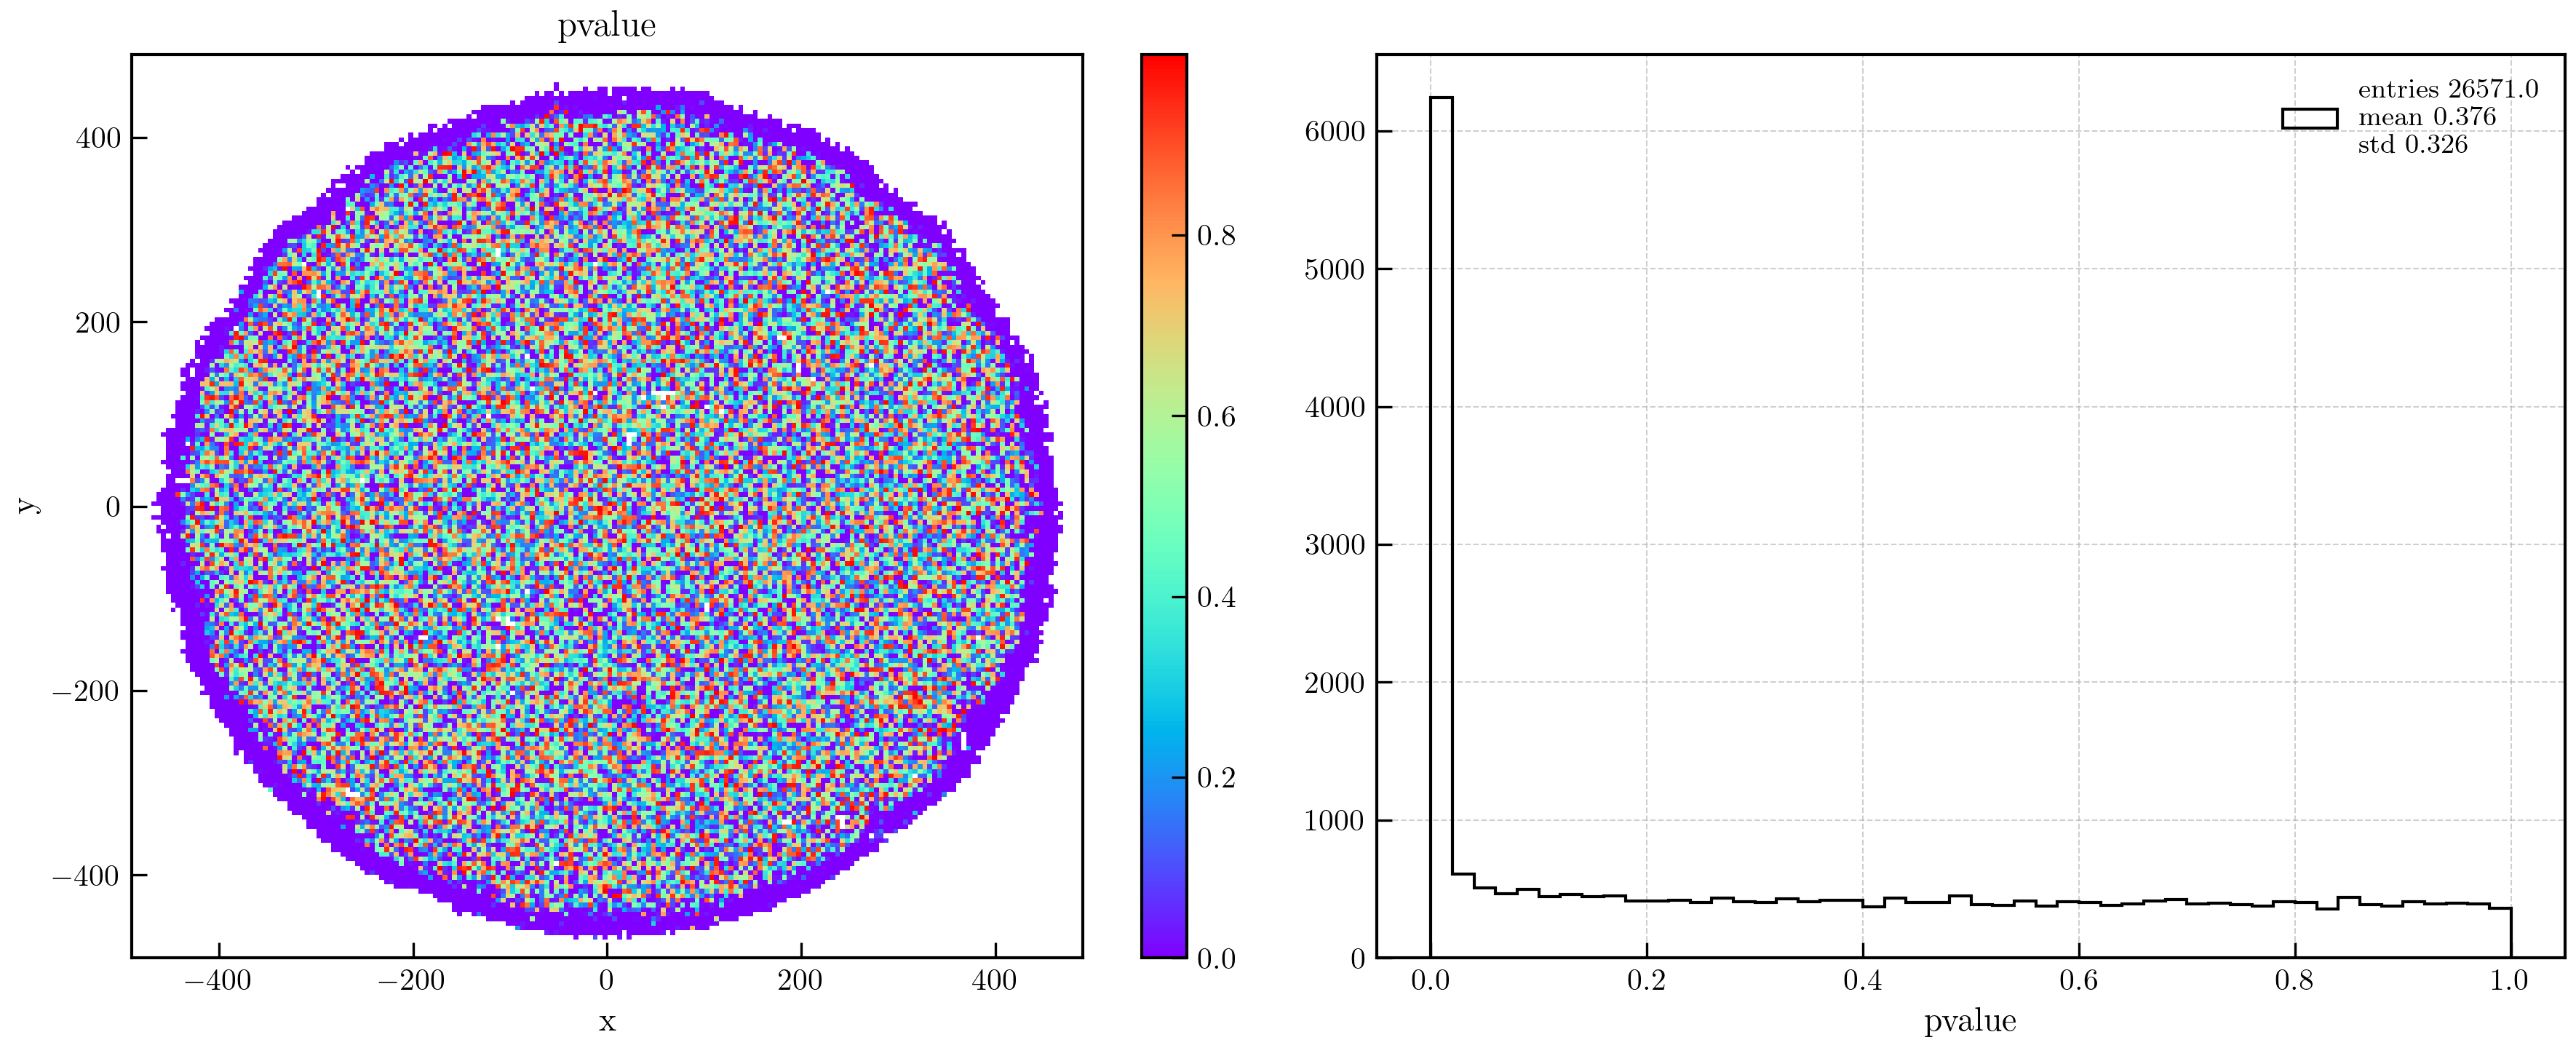

In [23]:
print(k2d.eref, k2d.lt)
prof.plot_profile(k2d.prof, stats = ('counts', 'mean', 'std', 'chi2', 'pvalue'));

### LT vs Radius

In [39]:
r      = np.sqrt(cdf.X**2 + cdf.Y**2)
dtime  = cdf.DT
ene    = prof.profile_scale((cdf.X, cdf.Y), cdf.S2e, k2d.prof, scale = 1.)
ene    = cdf.S2e 
rs     = np.linspace(50, 450, 42)
erefs, uerefs = [], []
lts, ults = [], []
for rmax in rs:
    rsel = r < rmax
    cc = krtool.lifetime(dtime[rsel], ene[rsel])
    erefs.append(cc[0]); uerefs.append(cc[1])
    lts.append(cc[2]); ults.append(cc[3])

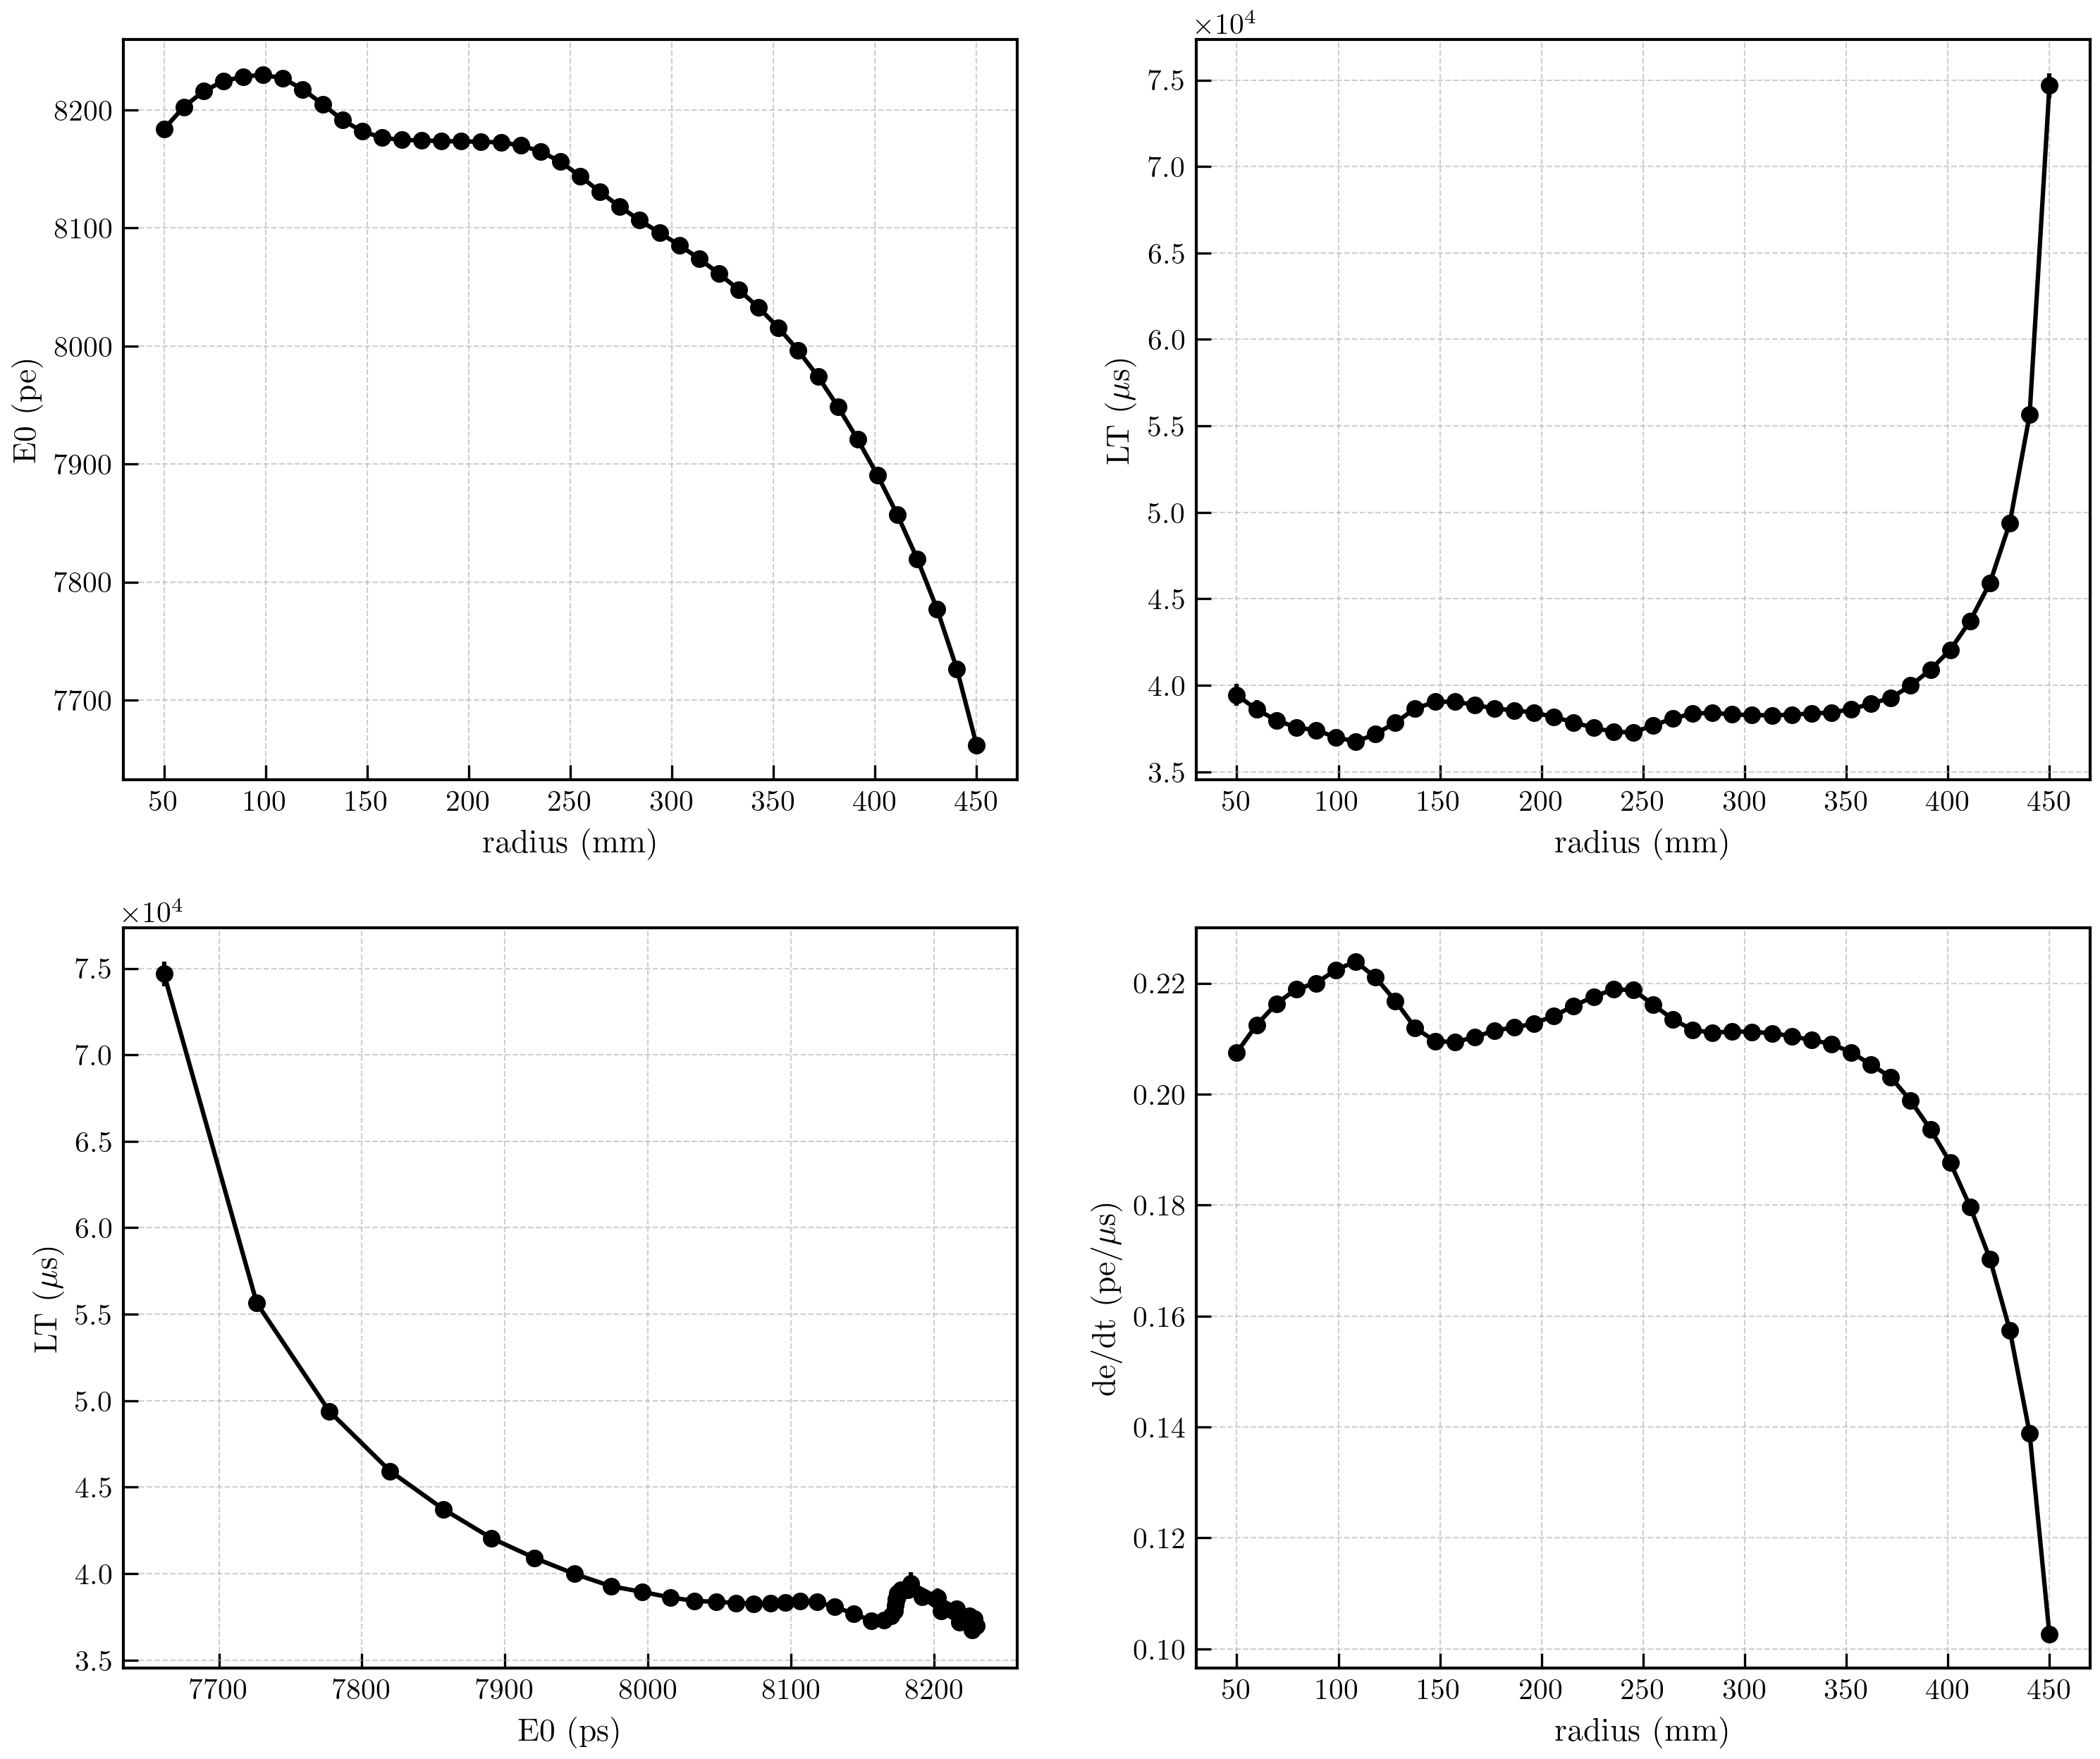

In [38]:
cv = pltext.canvas(4, 2)
cv(1)
plt.errorbar(rs, erefs, yerr = uerefs, fmt = 'o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel('E0 (pe)');
cv(2)
plt.errorbar(rs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel(r'LT ($\mu$s)');
cv(3)
plt.errorbar(erefs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('E0 (ps)'); plt.ylabel(r'LT ($\mu$s)');
cv(4)
dedt = np.array(erefs)/np.array(lts)
plt.errorbar(rs, dedt, fmt = 'o', ls = '-');
plt.xlabel('radius (mm)'); plt.ylabel(r'de/dt (pe/$\mu$s)');


In [40]:
r      = np.sqrt(cdf.X**2 + cdf.Y**2)
dtime  = cdf.DT
ene    = prof.profile_scale((cdf.X, cdf.Y), cdf.S2e, k2d.prof, scale = 1.)
#ene    = cdf.S2e 
rs     = np.linspace(50, 450, 42)
erefs, uerefs = [], []
lts, ults = [], []
for rmax in rs:
    rsel = r < rmax
    cc = krtool.lifetime(dtime[rsel], ene[rsel])
    erefs.append(cc[0]); uerefs.append(cc[1])
    lts.append(cc[2]); ults.append(cc[3])

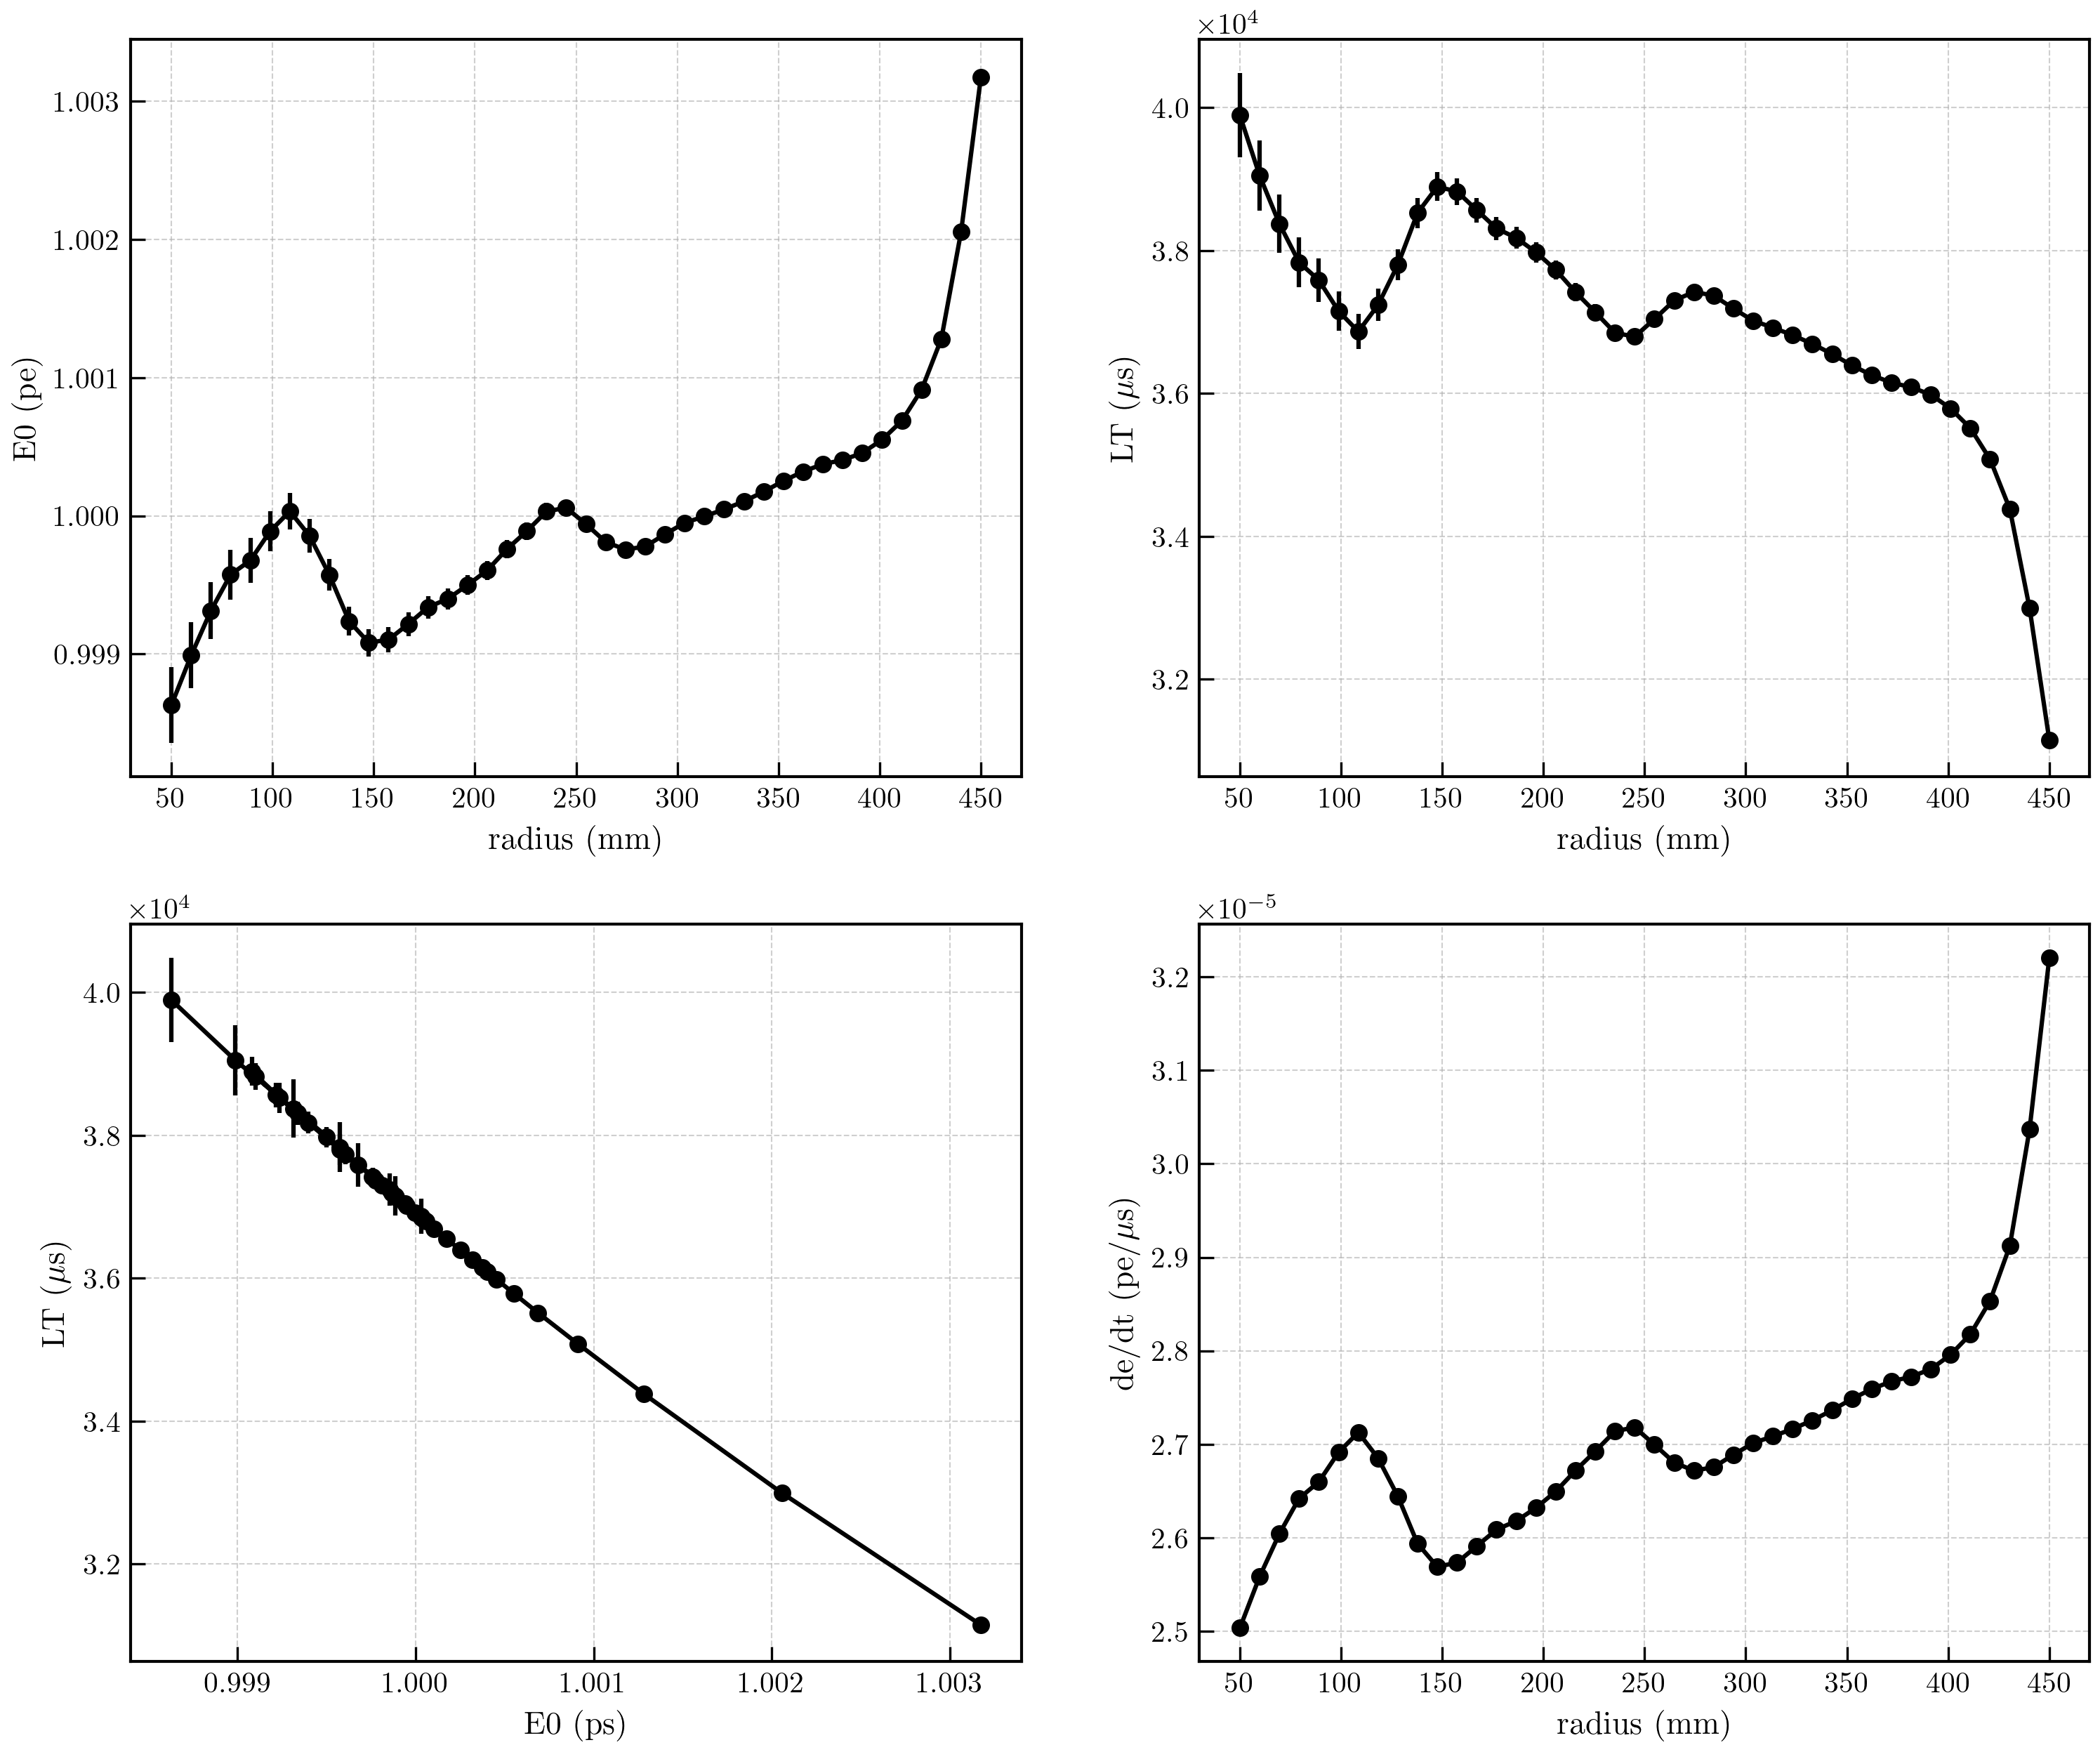

In [41]:
cv = pltext.canvas(4, 2)
cv(1)
plt.errorbar(rs, erefs, yerr = uerefs, fmt = 'o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel('E0 (pe)');
cv(2)
plt.errorbar(rs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel(r'LT ($\mu$s)');
cv(3)
plt.errorbar(erefs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('E0 (ps)'); plt.ylabel(r'LT ($\mu$s)');
cv(4)
dedt = np.array(erefs)/np.array(lts)
plt.errorbar(rs, dedt, fmt = 'o', ls = '-');
plt.xlabel('radius (mm)'); plt.ylabel(r'de/dt (pe/$\mu$s)');

## Compare LT map, LT Unique, 3D

In [242]:
krf, res_1 = krtool.krmap((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins)
cene_1     = krtool.krmap_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, krf, scale = 41.5)

In [243]:
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins, rmax = 350., boost = True)
cene_2     = krtool.krmap_ltunique_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, k2d, scale = 41.5)

In [244]:
k3d, res_3 = prof.profile((cdf.X, cdf.Y, cdf.DT), cdf.S2e, bins = (68, 68, 10)) 
cene_3     = prof.profile_scale((cdf.X, cdf.Y, cdf.DT), cdf.S2e, k3d, 41.5)

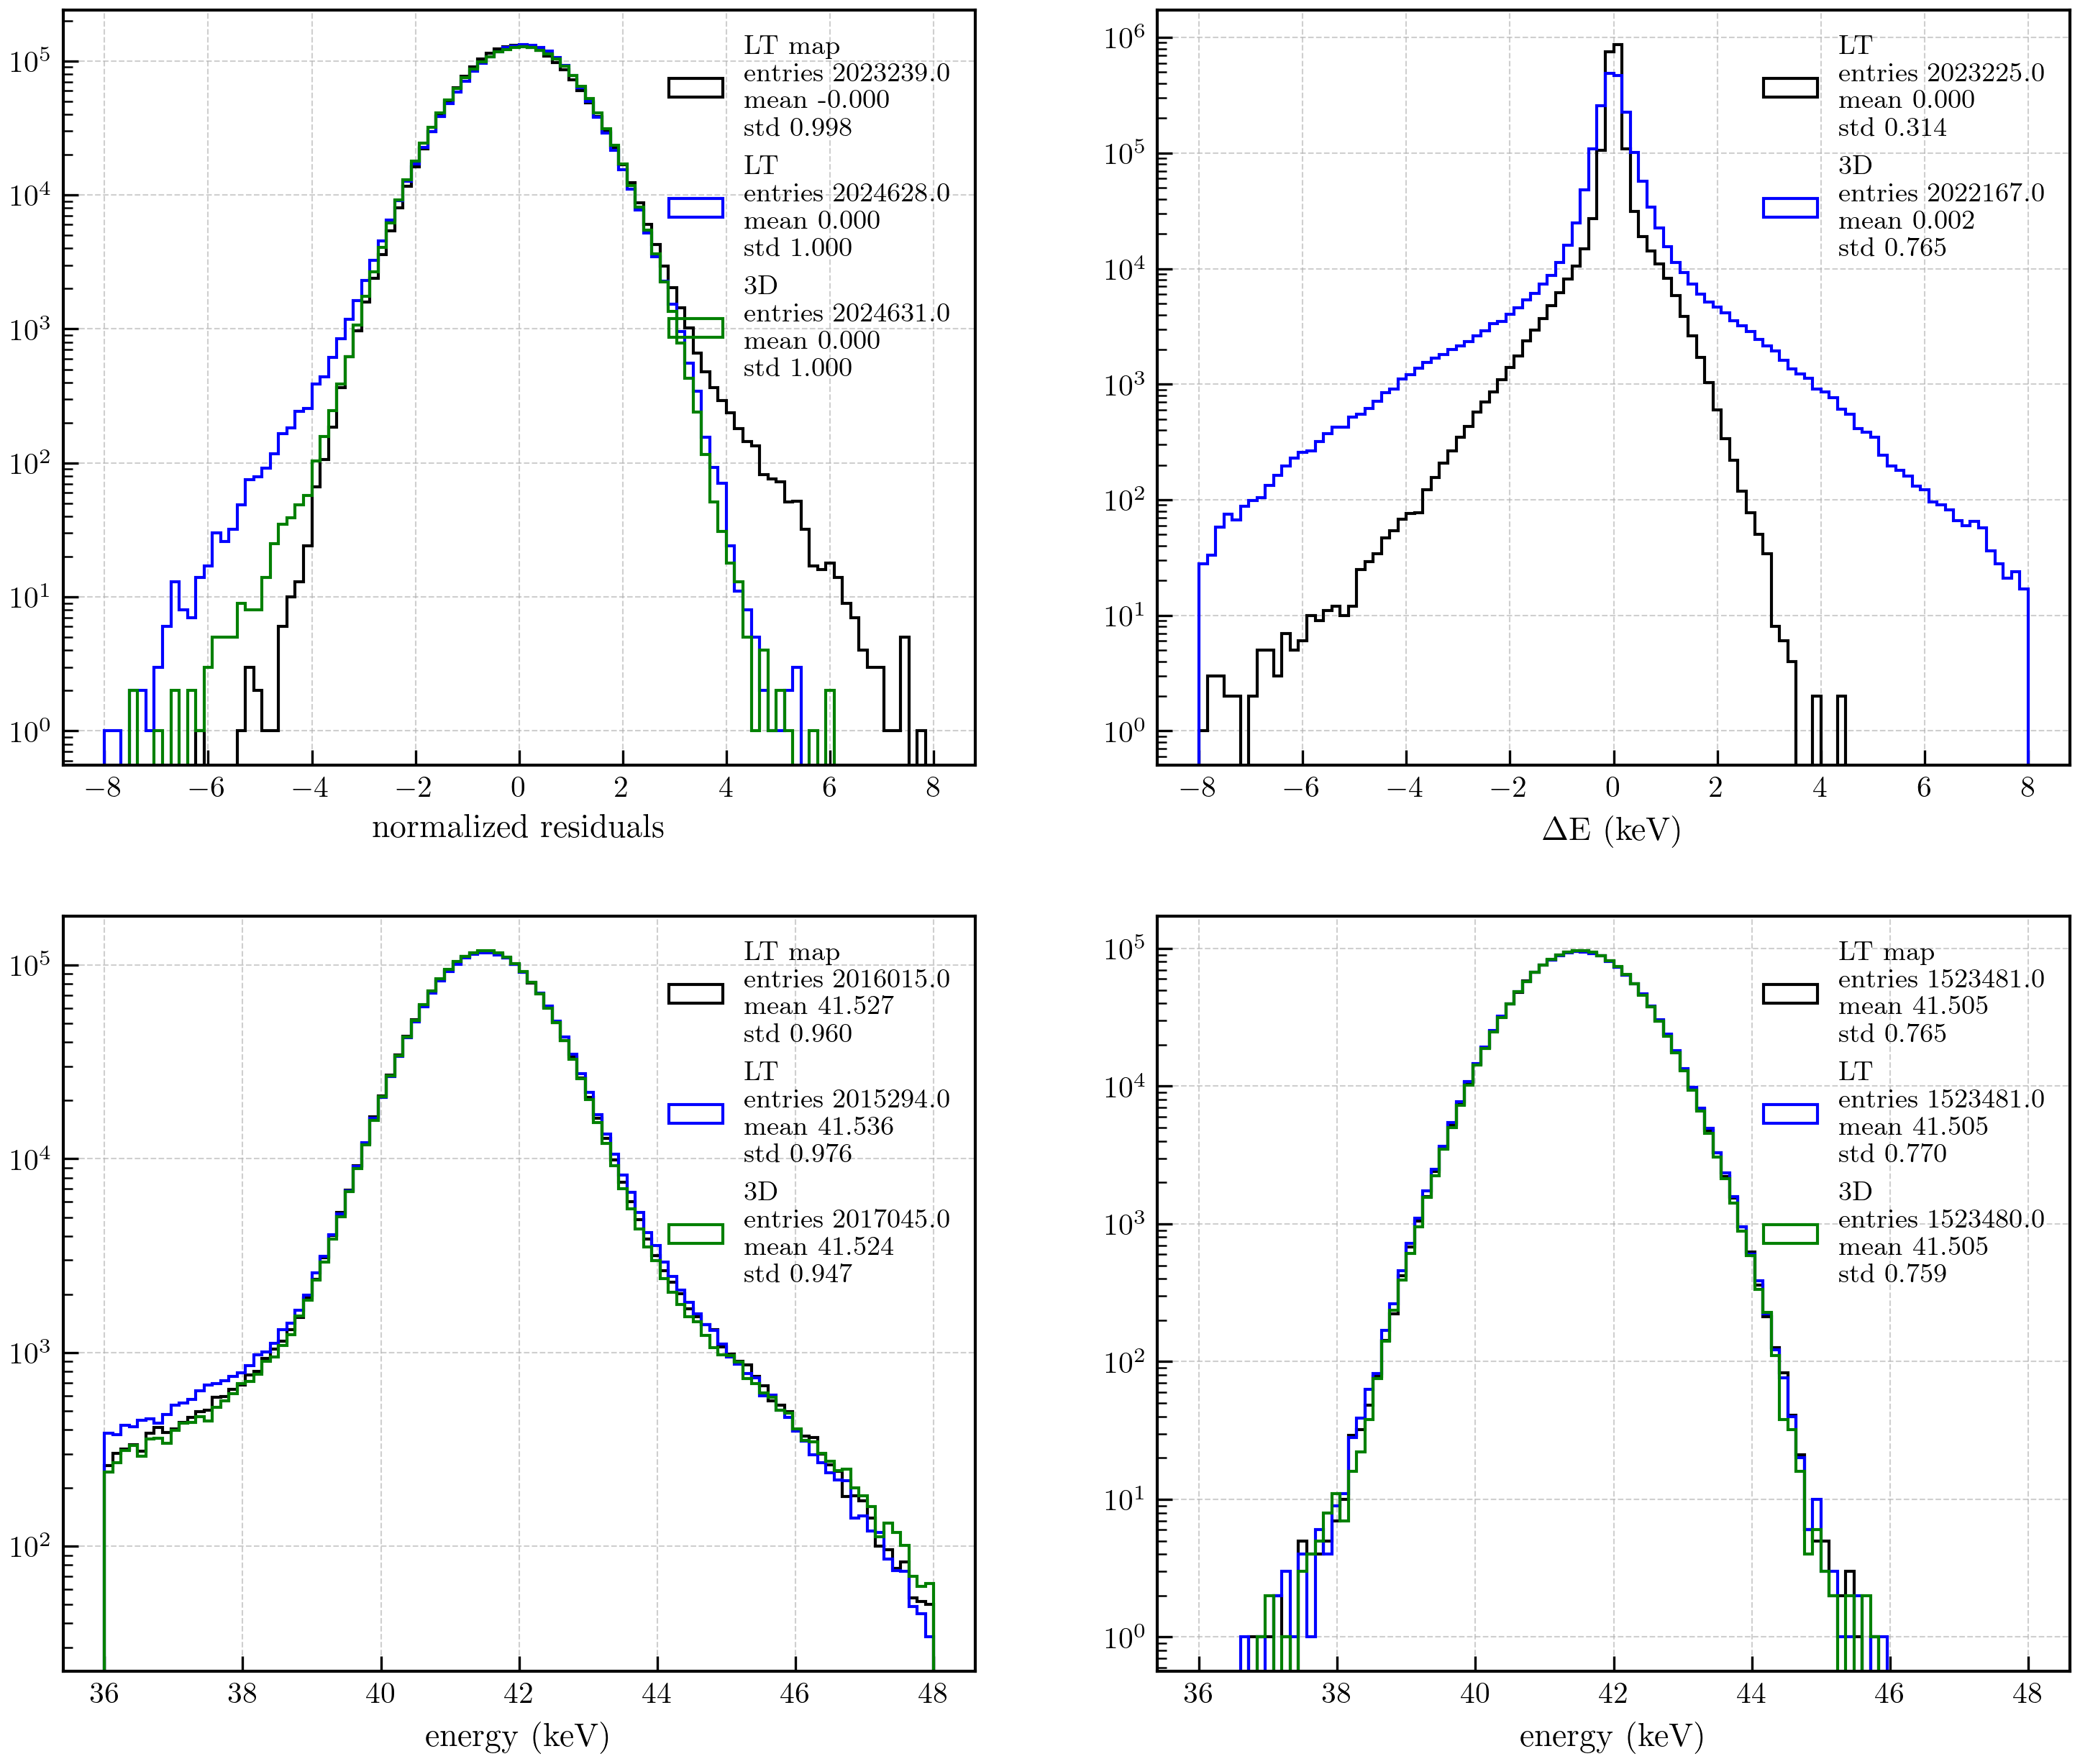

In [245]:
rsel = cdf.R < 400.
cv = pltext.canvas(4, 2)
cv(1);
pltext.hist(res_1, 100, (-8, 8), label = 'LT map'); 
pltext.hist(res_2, 100, (-8, 8), label = 'LT');
pltext.hist(res_3, 100, (-8, 8), label = '3D'); 
plt.yscale('log'); plt.xlabel("normalized residuals"); plt.legend();
cv(2);
pltext.hist(cene_2 - cene_1, 100, (-8, 8), label = r'LT');
pltext.hist(cene_3 - cene_1, 100, (-8, 8), label = r'3D');
plt.yscale('log'); plt.xlabel(r"$\Delta$E (keV)");
cv(3);
pltext.hist(cene_1, 100, (36, 48), label = 'LT map');
pltext.hist(cene_2, 100, (36, 48), label = 'LT'); 
pltext.hist(cene_3, 100, (36, 48), label = '3D');
plt.yscale('log'); plt.xlabel("energy (keV)"); plt.legend();
cv(4)
pltext.hist(cene_1[rsel], 100, (36, 48), label = 'LT map');
pltext.hist(cene_2[rsel], 100, (36, 48), label = 'LT'); 
pltext.hist(cene_3[rsel], 100, (36, 48), label = '3D'); 
plt.yscale('log'); plt.xlabel("energy (keV)"); plt.legend();


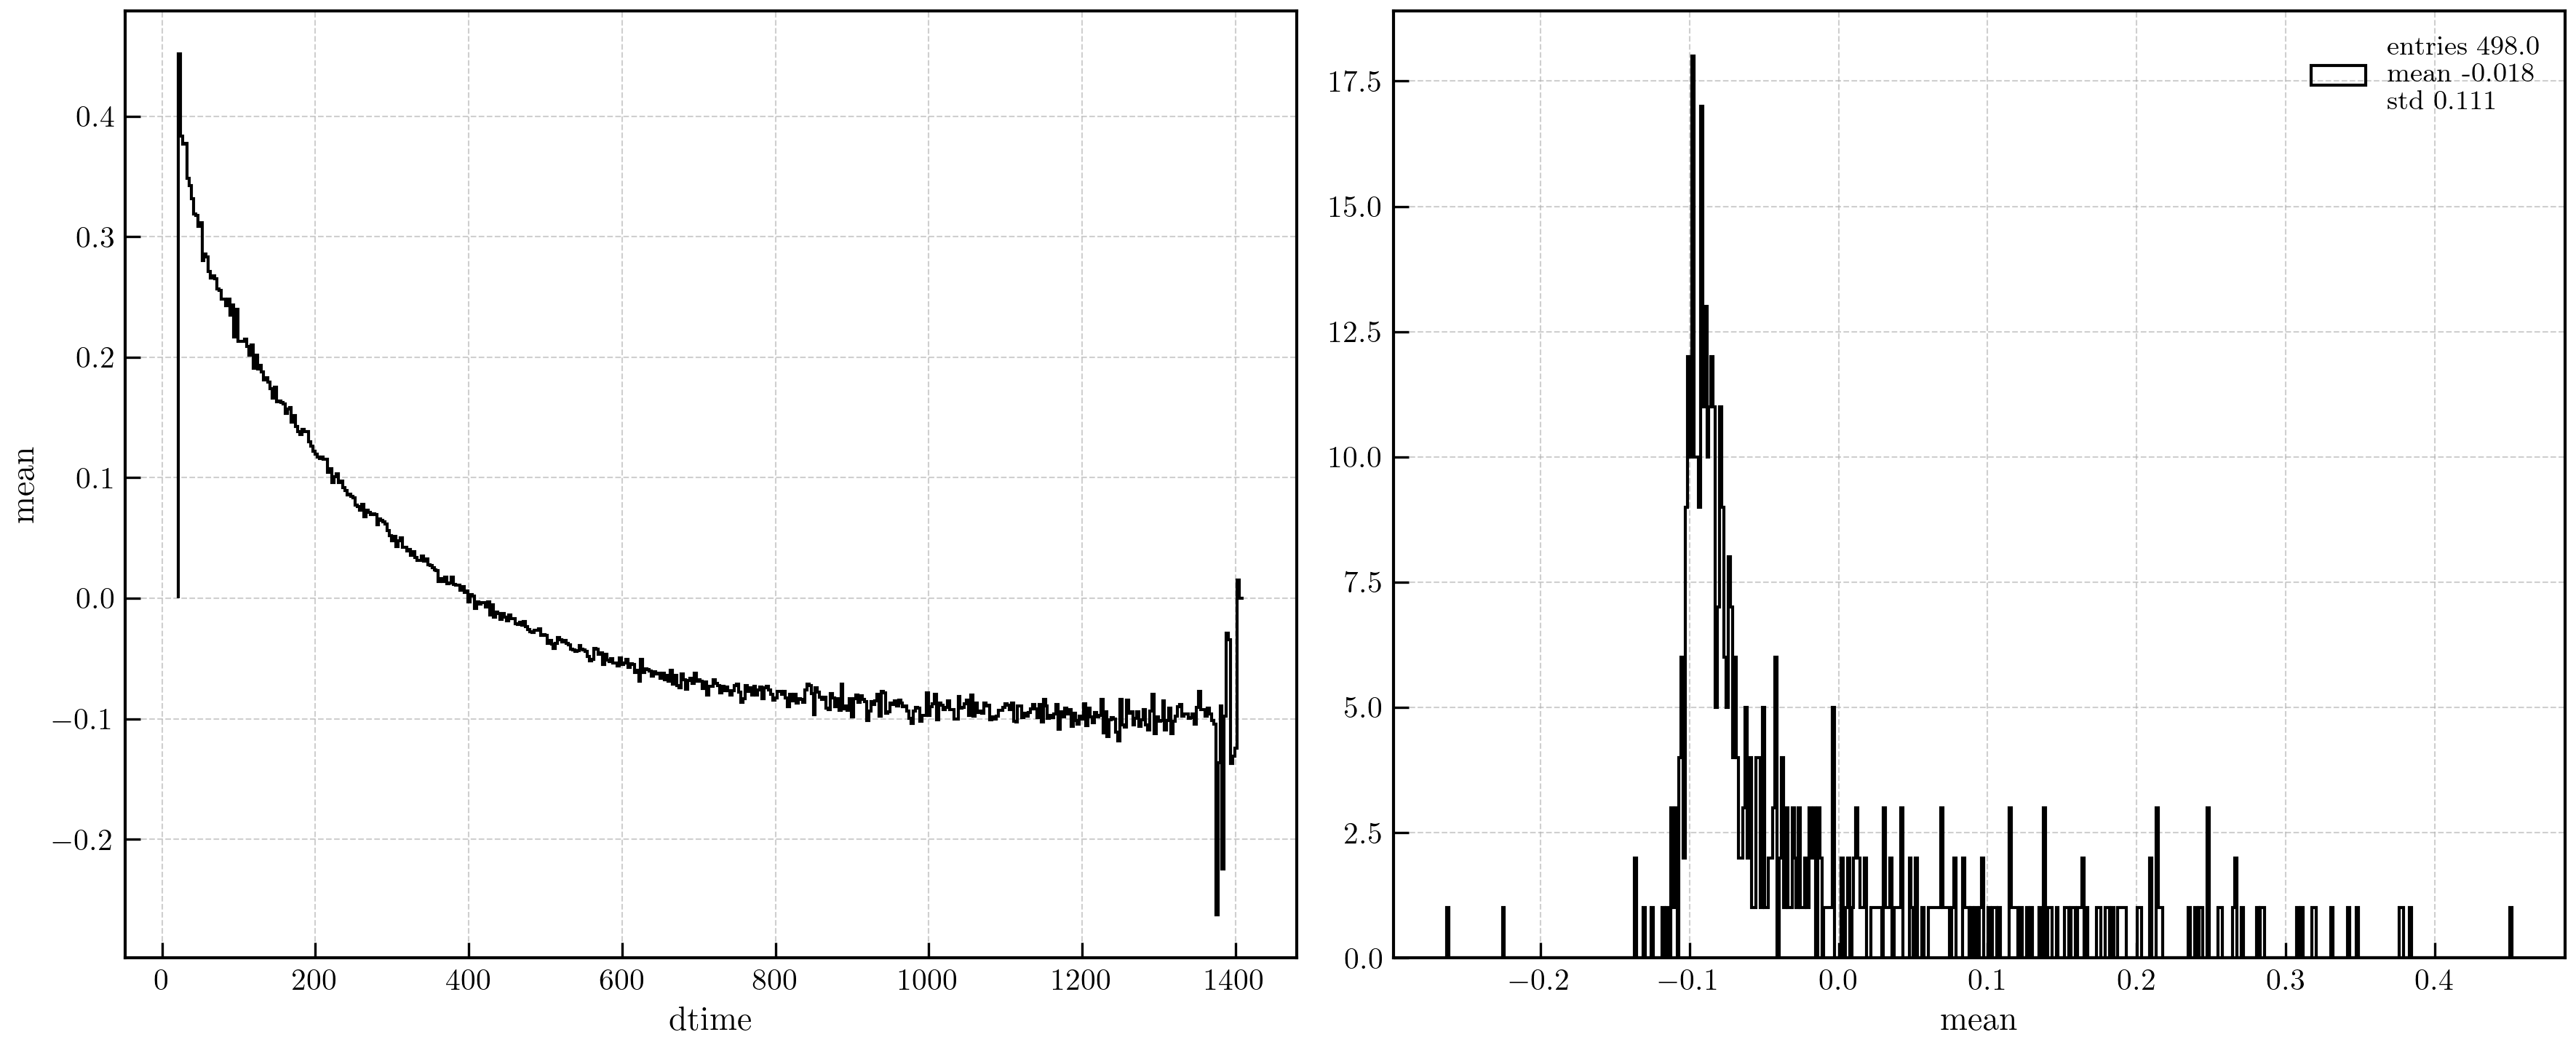

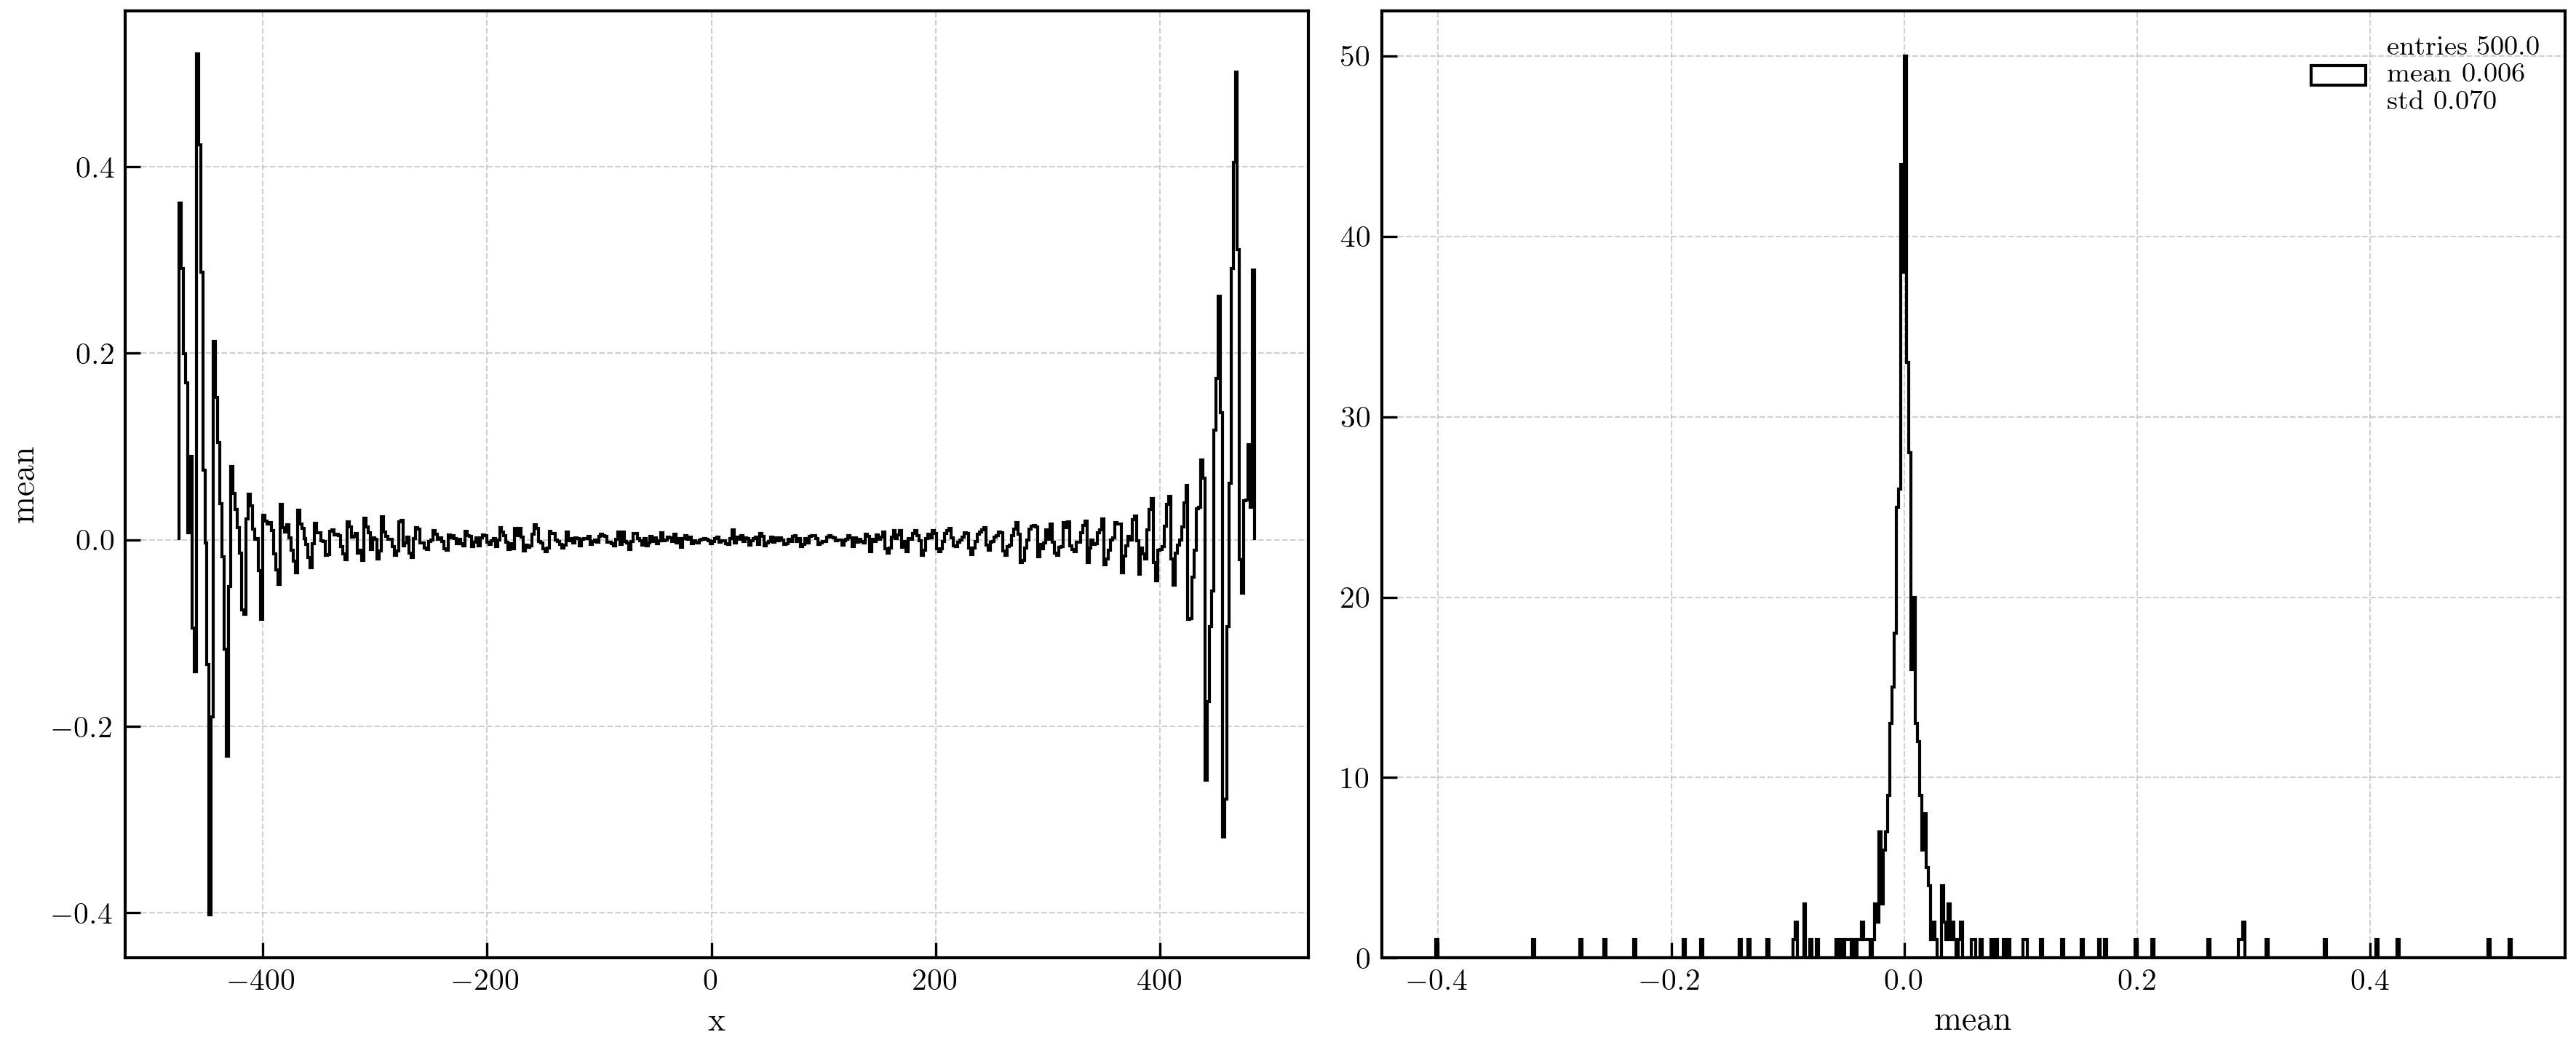

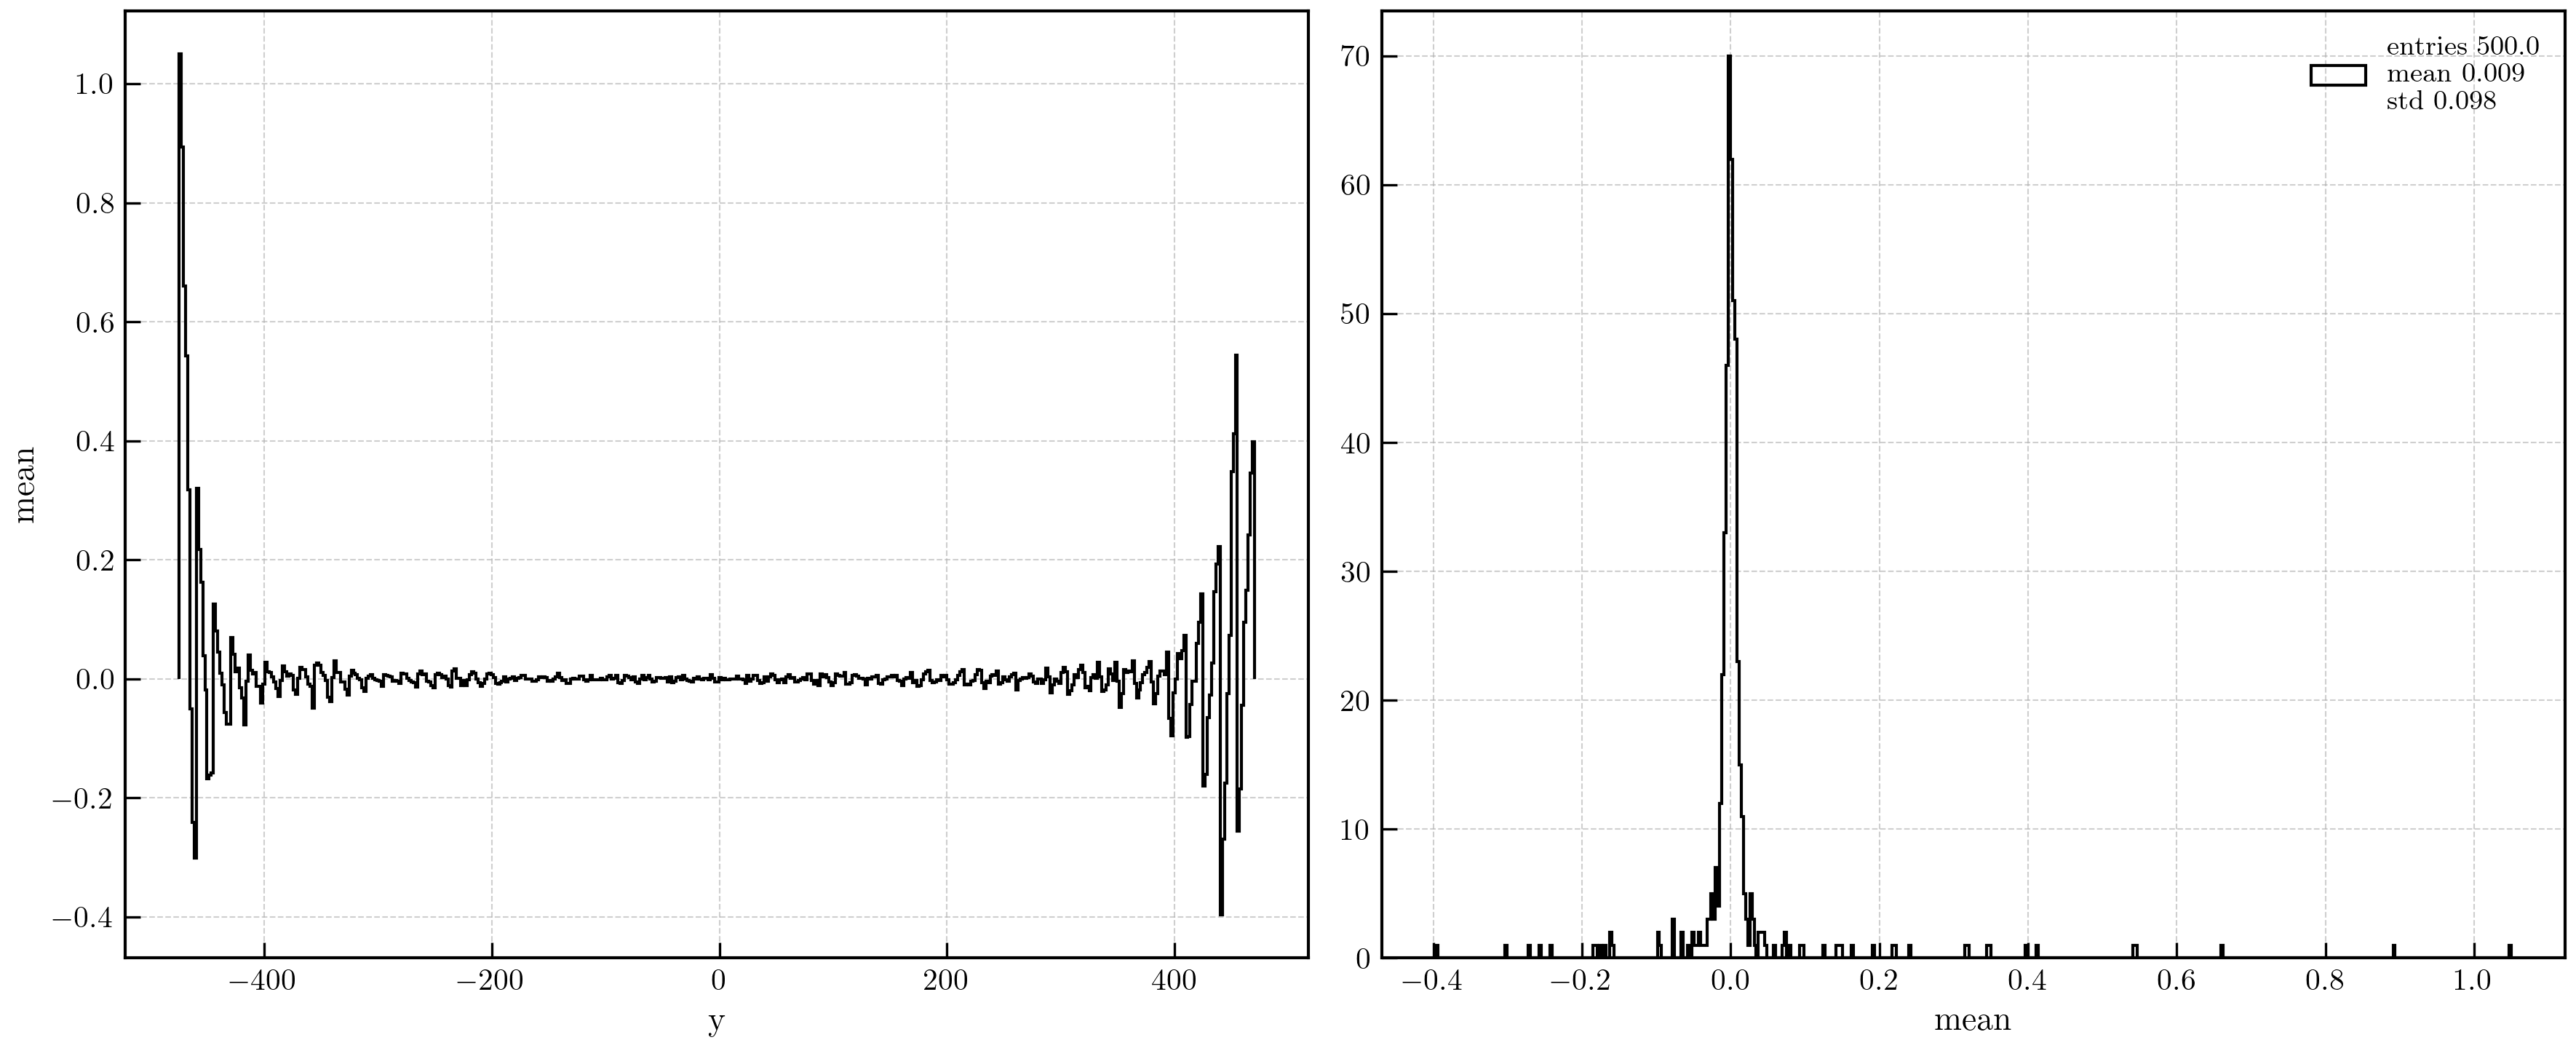

In [246]:
dene = cene_2 - cene_1
xsel = ~np.isnan(dene)
xdf = pd.DataFrame({'x' : cdf[xsel].X, 'y' : cdf[xsel].Y, 'dtime' : cdf[xsel].DT, 'energy': dene[xsel]})
krtool.plot_xydt_energy_profiles(xdf, nbins = 500)

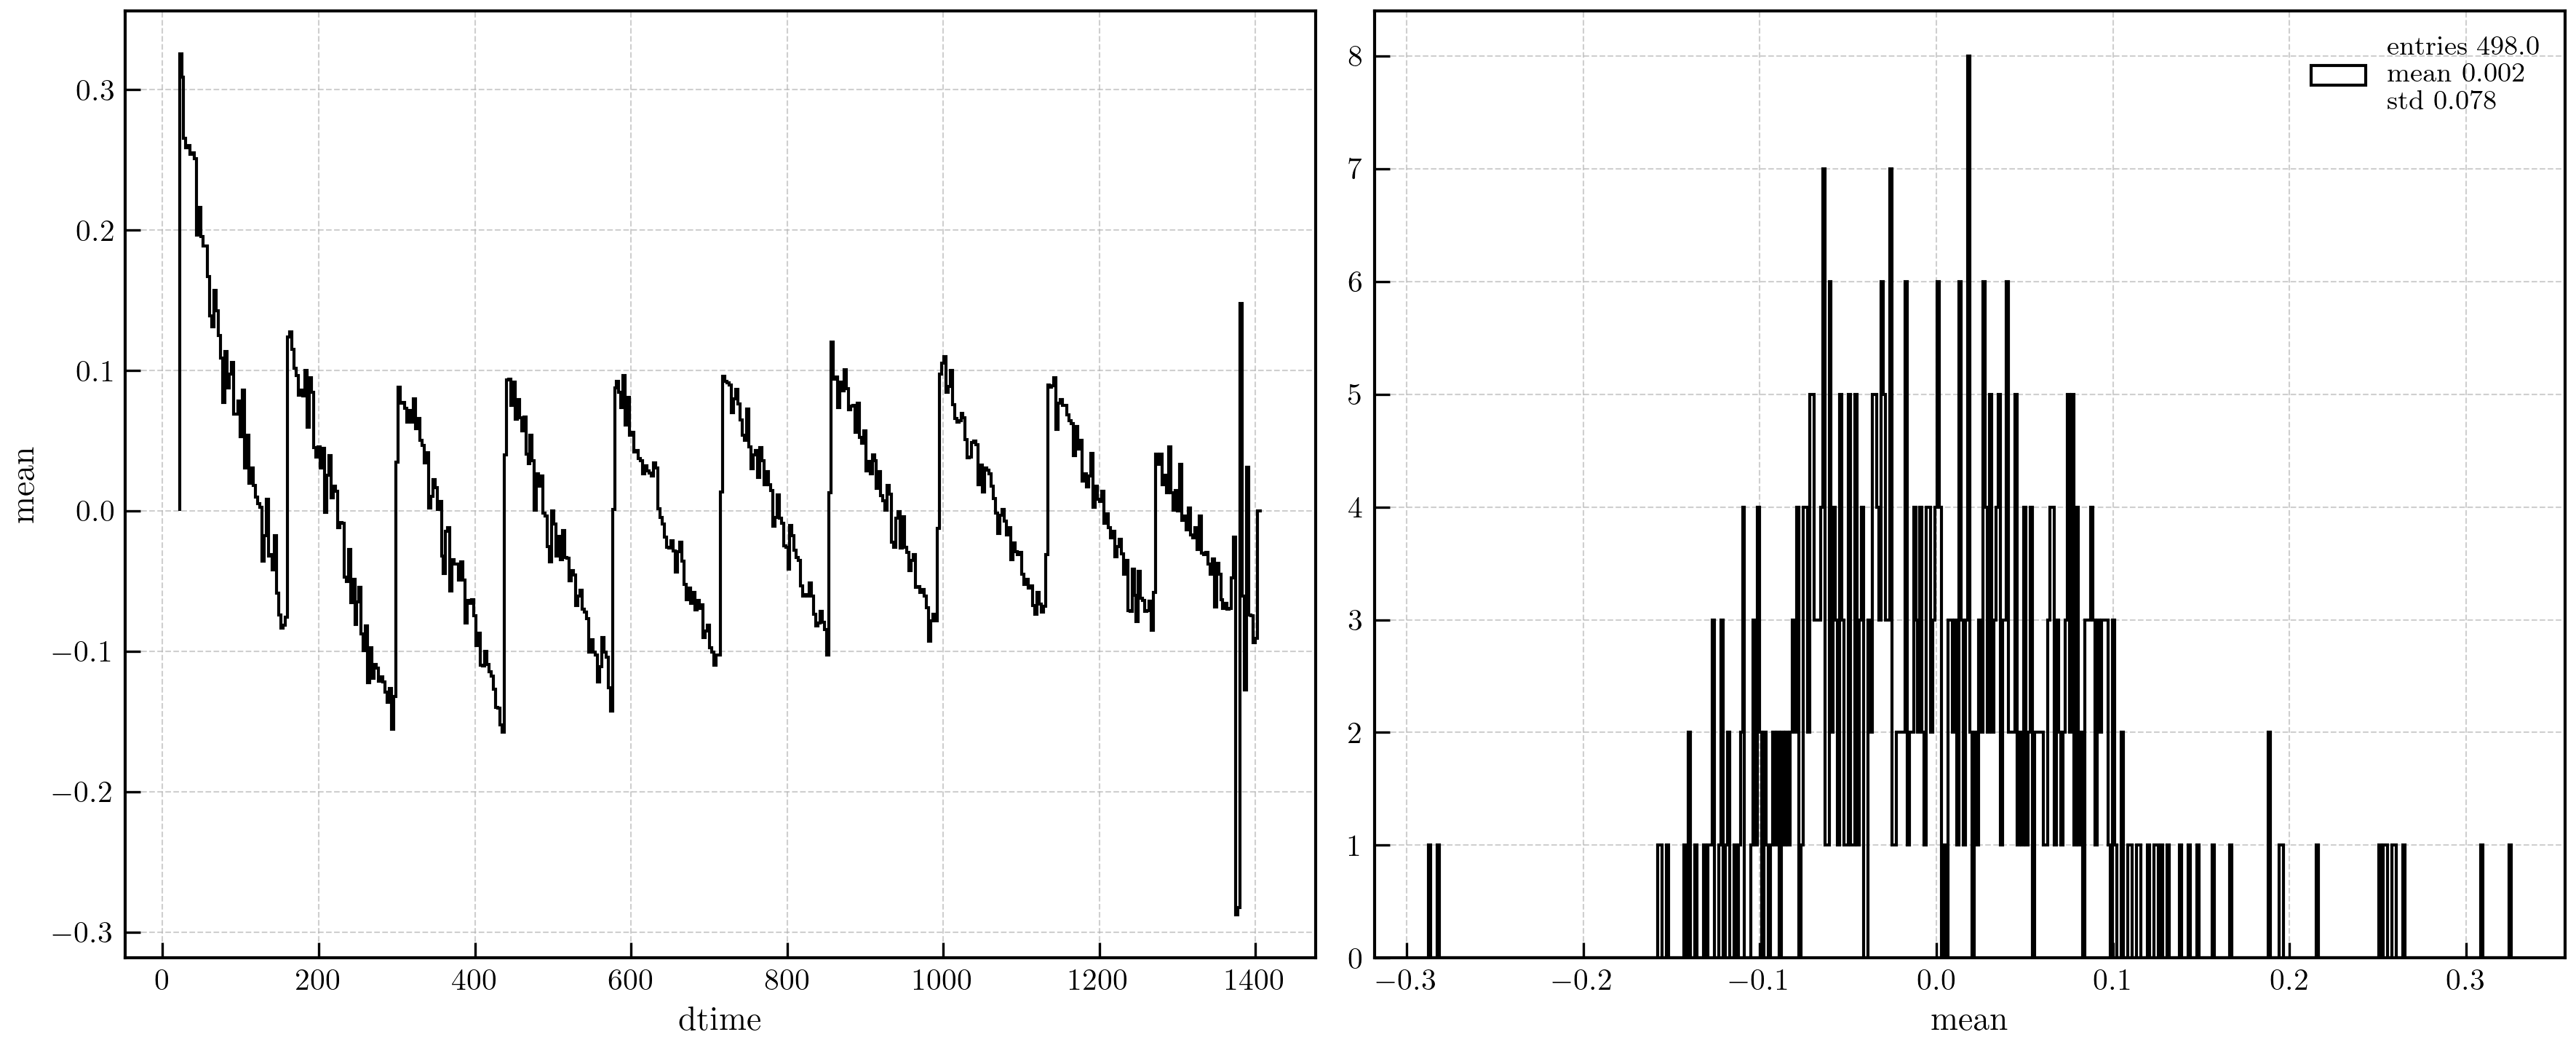

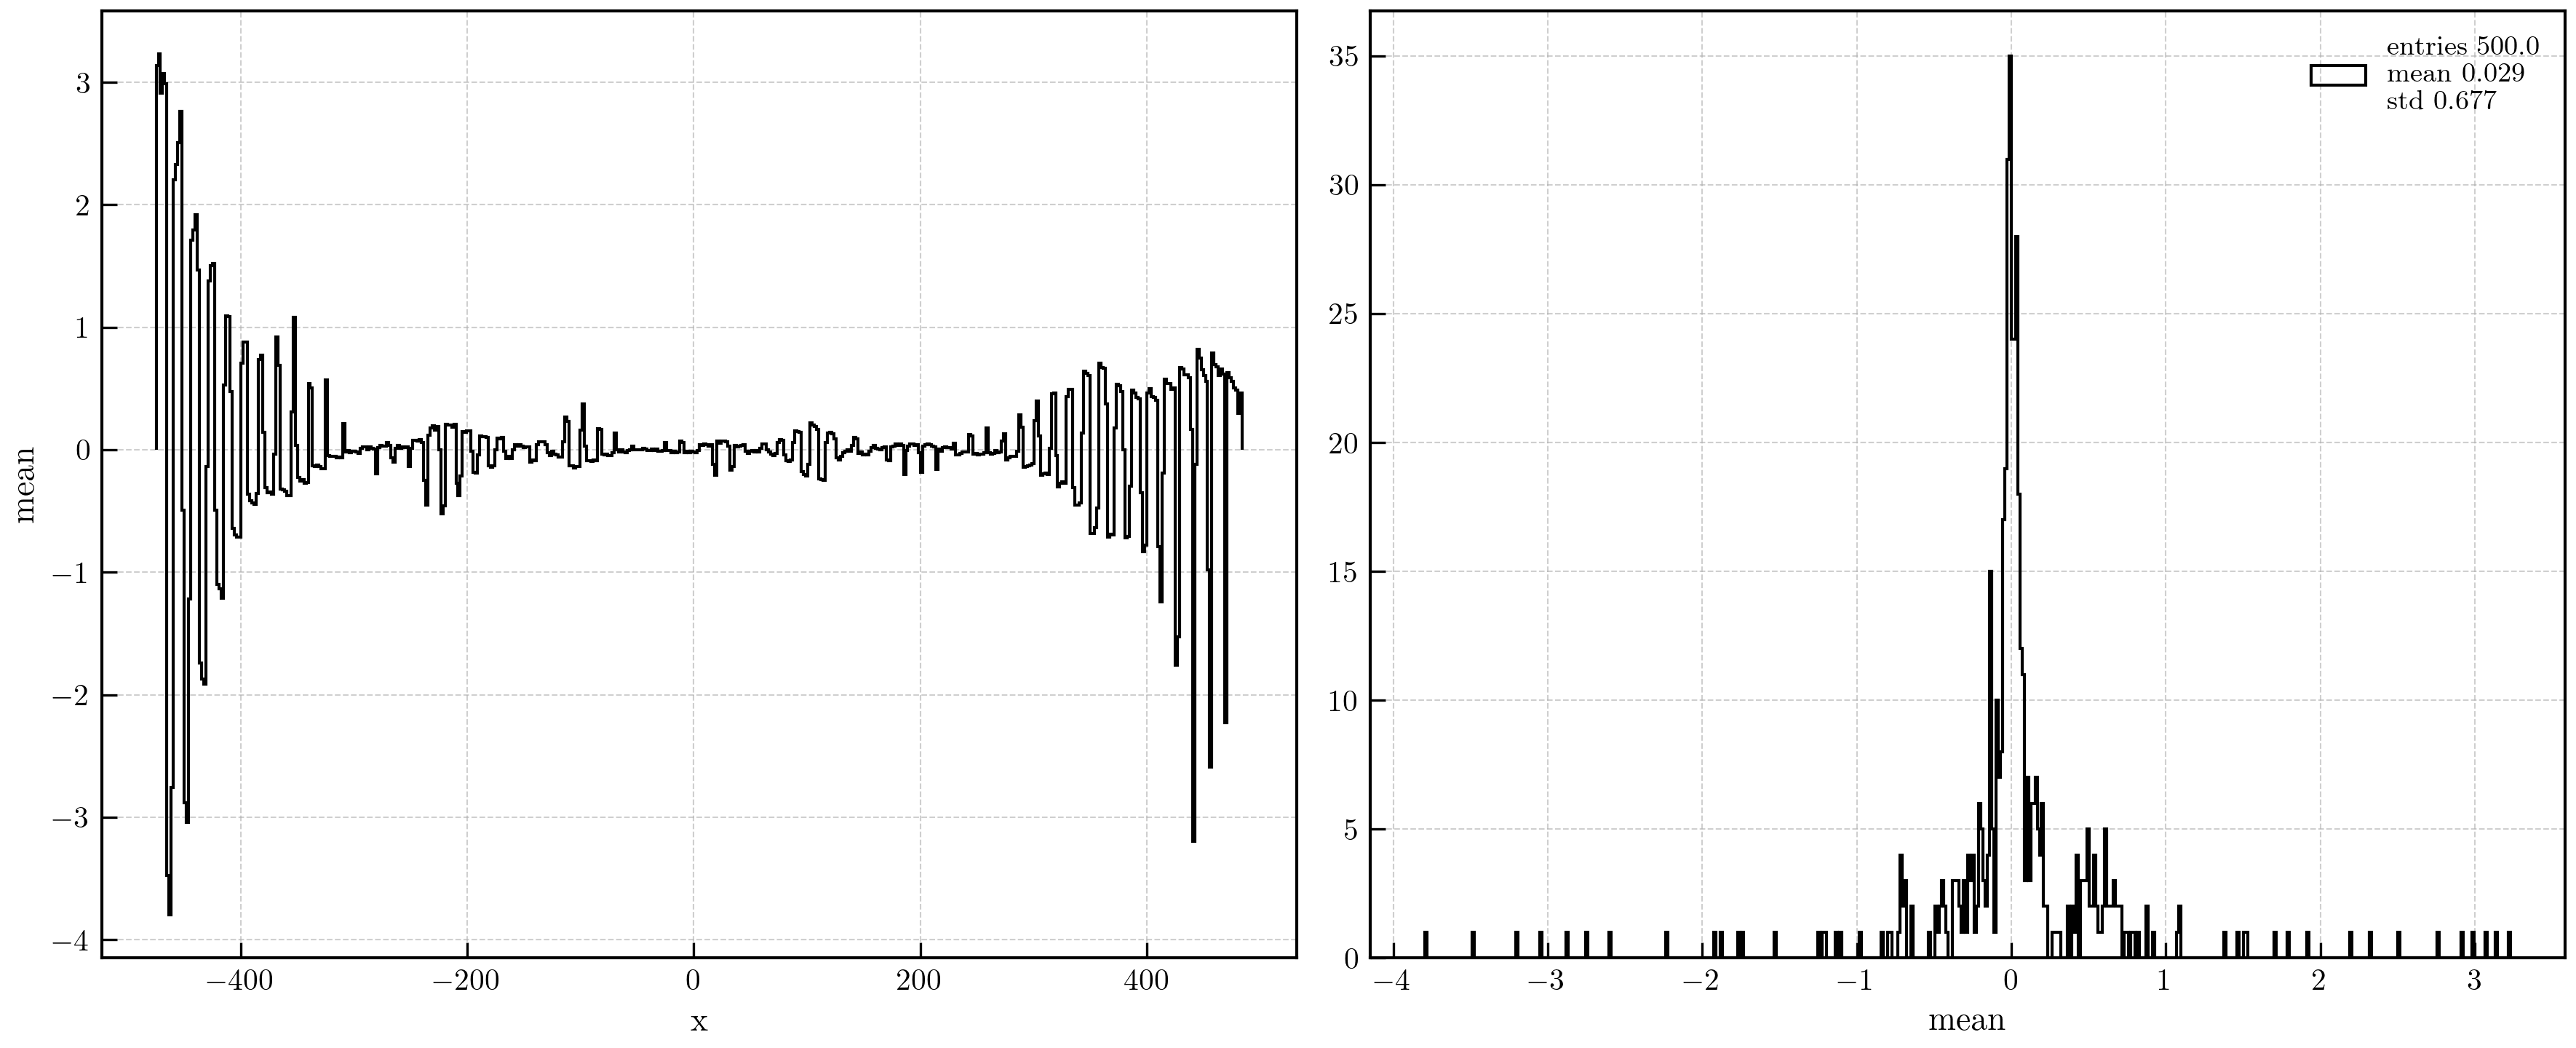

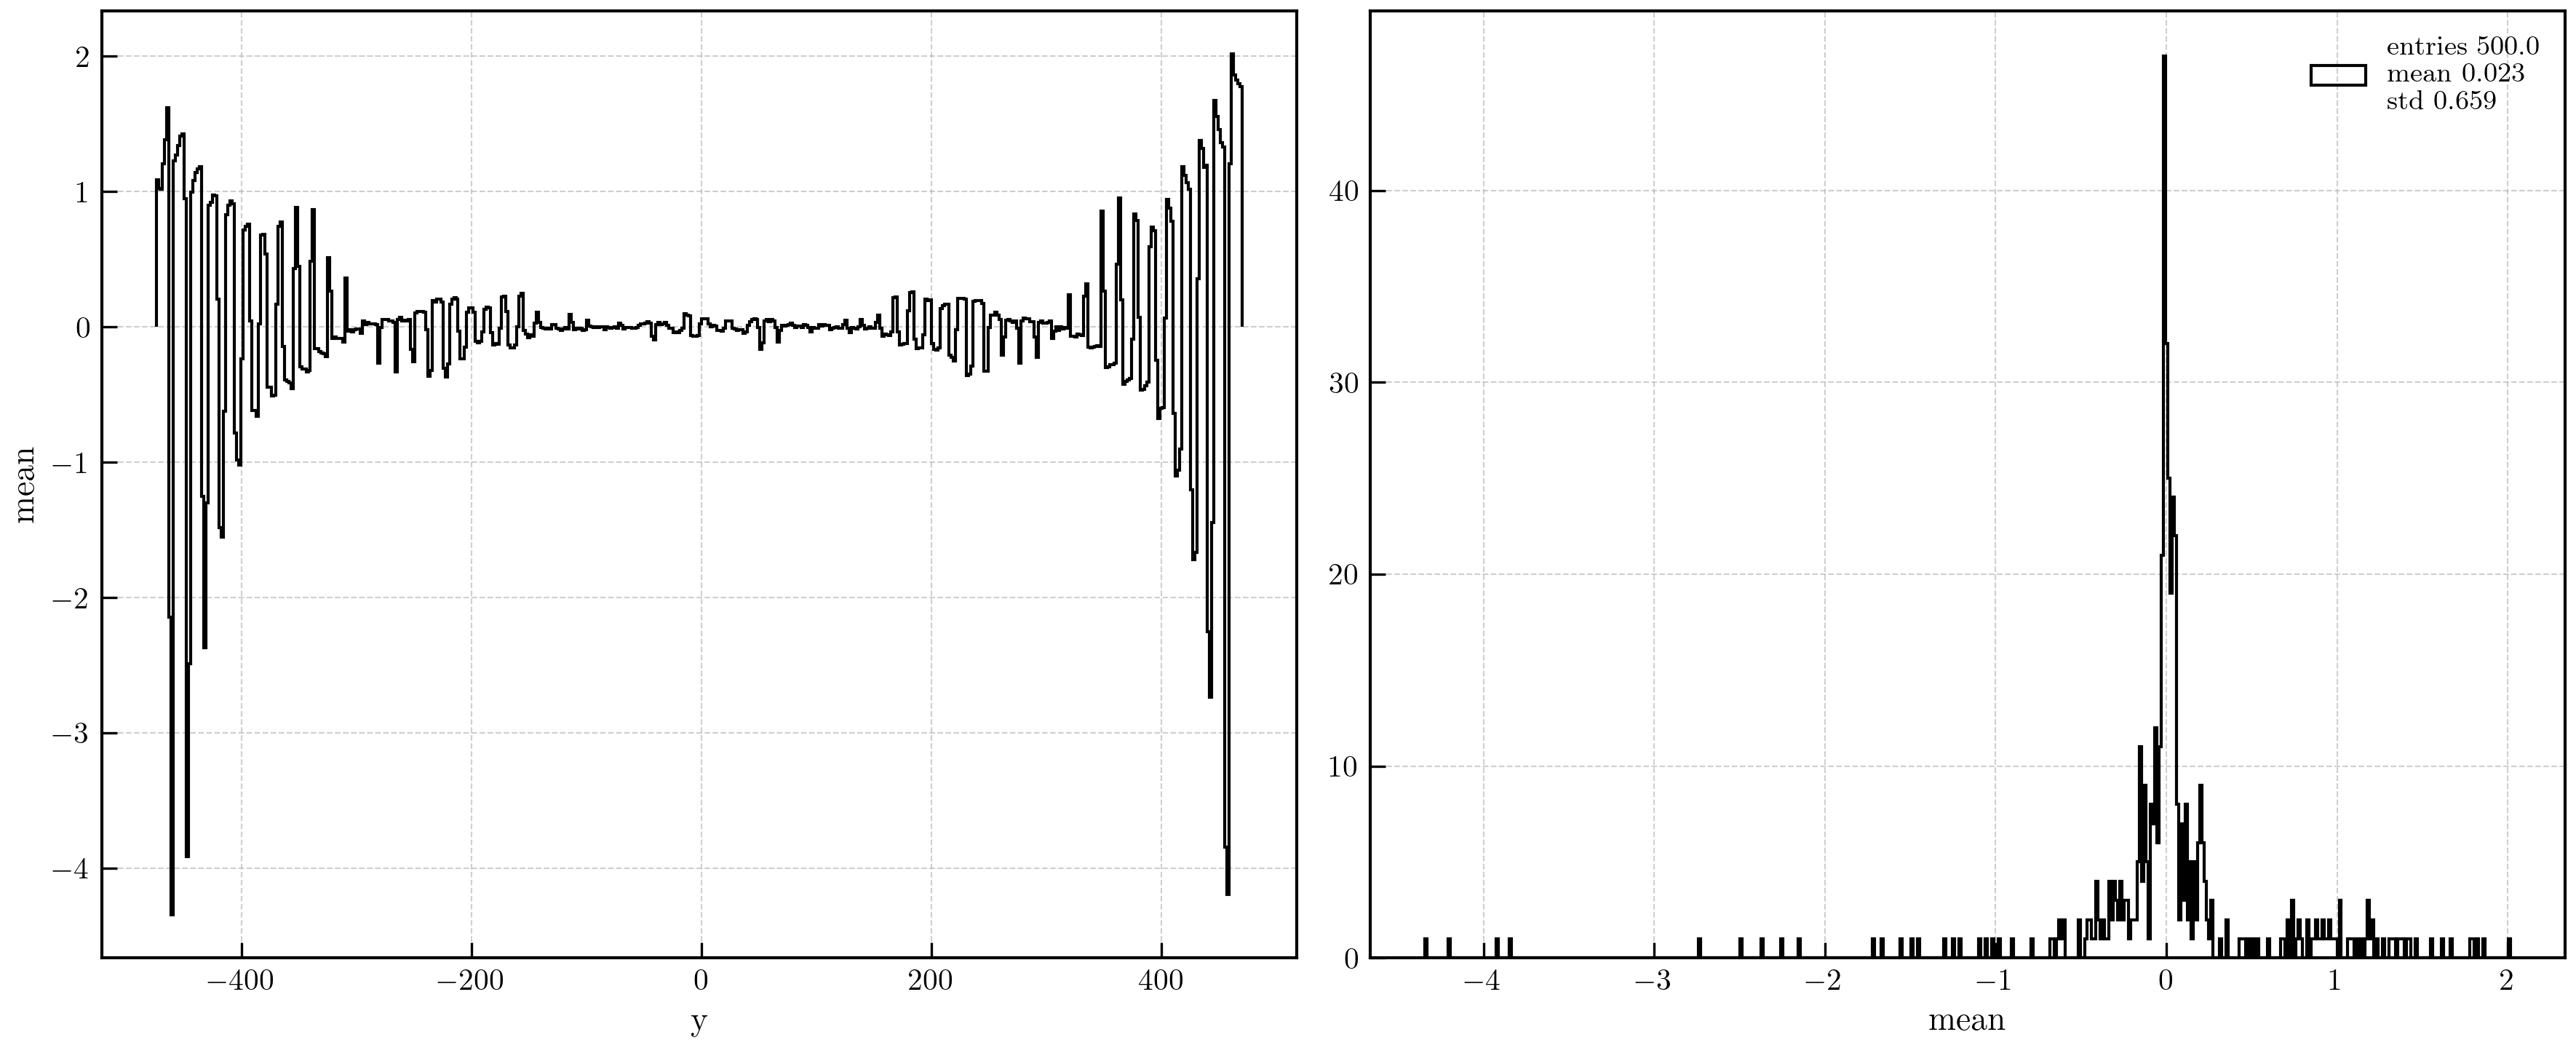

In [247]:
dene = cene_3 - cene_1
xsel = ~np.isnan(dene)
xdf = pd.DataFrame({'x' : cdf[xsel].X, 'y' : cdf[xsel].Y, 'dtime' : cdf[xsel].DT, 'energy': dene[xsel]})
krtool.plot_xydt_energy_profiles(xdf, nbins = 500)

## Unique LT map

In [157]:
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins, rmax = 350.)

In [159]:
cene_2 = krtool.krmap_ltunique_scale((cdf.X, cdf.Y), cdf.DT, cdf.S2e, k2d, scale = 41.5)

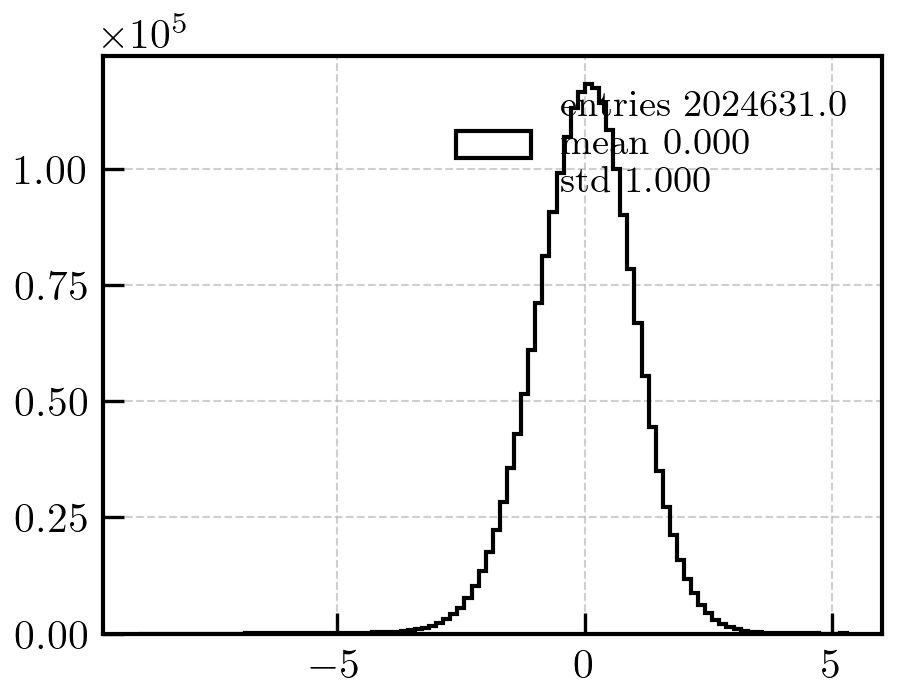

In [160]:
pltext.hist(res_2, 100);

In [ ]:
coors, dtime, energy = (cdf.X, cdf.Y), cdf.DT, cdf.S2e
r    = np.sqrt(cdf.X**2 + cdf.Y**2)

In [ ]:
def lt_un(dtime, energy):
    ts   = dtime
    enes = energy
    st_fun = lambda ts, a, b : a - b * ts
    par, var = optimize.curve_fit(st_fun, ts, enes)
    eref  = par[0]
    dedt  = par[1]
    ueref = np.sqrt(var[0, 0])
    udedt = np.sqrt(var[1, 1])
    lt    = eref/dedt
    ult   = np.sqrt((ueref/dedt)**2 + (lt * udedt/dedt)**2)  
    return eref, ueref, lt, ult

In [ ]:
coors, dtime, energy = (cdf.X, cdf.Y), cdf.DT, cdf.S2e
r    = np.sqrt(cdf.X**2 + cdf.Y**2)
rs   = np.linspace(100, 450, 20)
print(rs)
erefs, uerefs = [], []
lts, ults = [], []
for rmax in rs:
    rsel = r < rmax
    cc = lt_unique(dtime[rsel], energy[rsel])
    erefs.append(cc[0]); uerefs.append(cc[1])
    lts.append(cc[2]); ults.append(cc[3])

[100.         118.42105263 136.84210526 155.26315789 173.68421053
 192.10526316 210.52631579 228.94736842 247.36842105 265.78947368
 284.21052632 302.63157895 321.05263158 339.47368421 357.89473684
 376.31578947 394.73684211 413.15789474 431.57894737 450.        ]


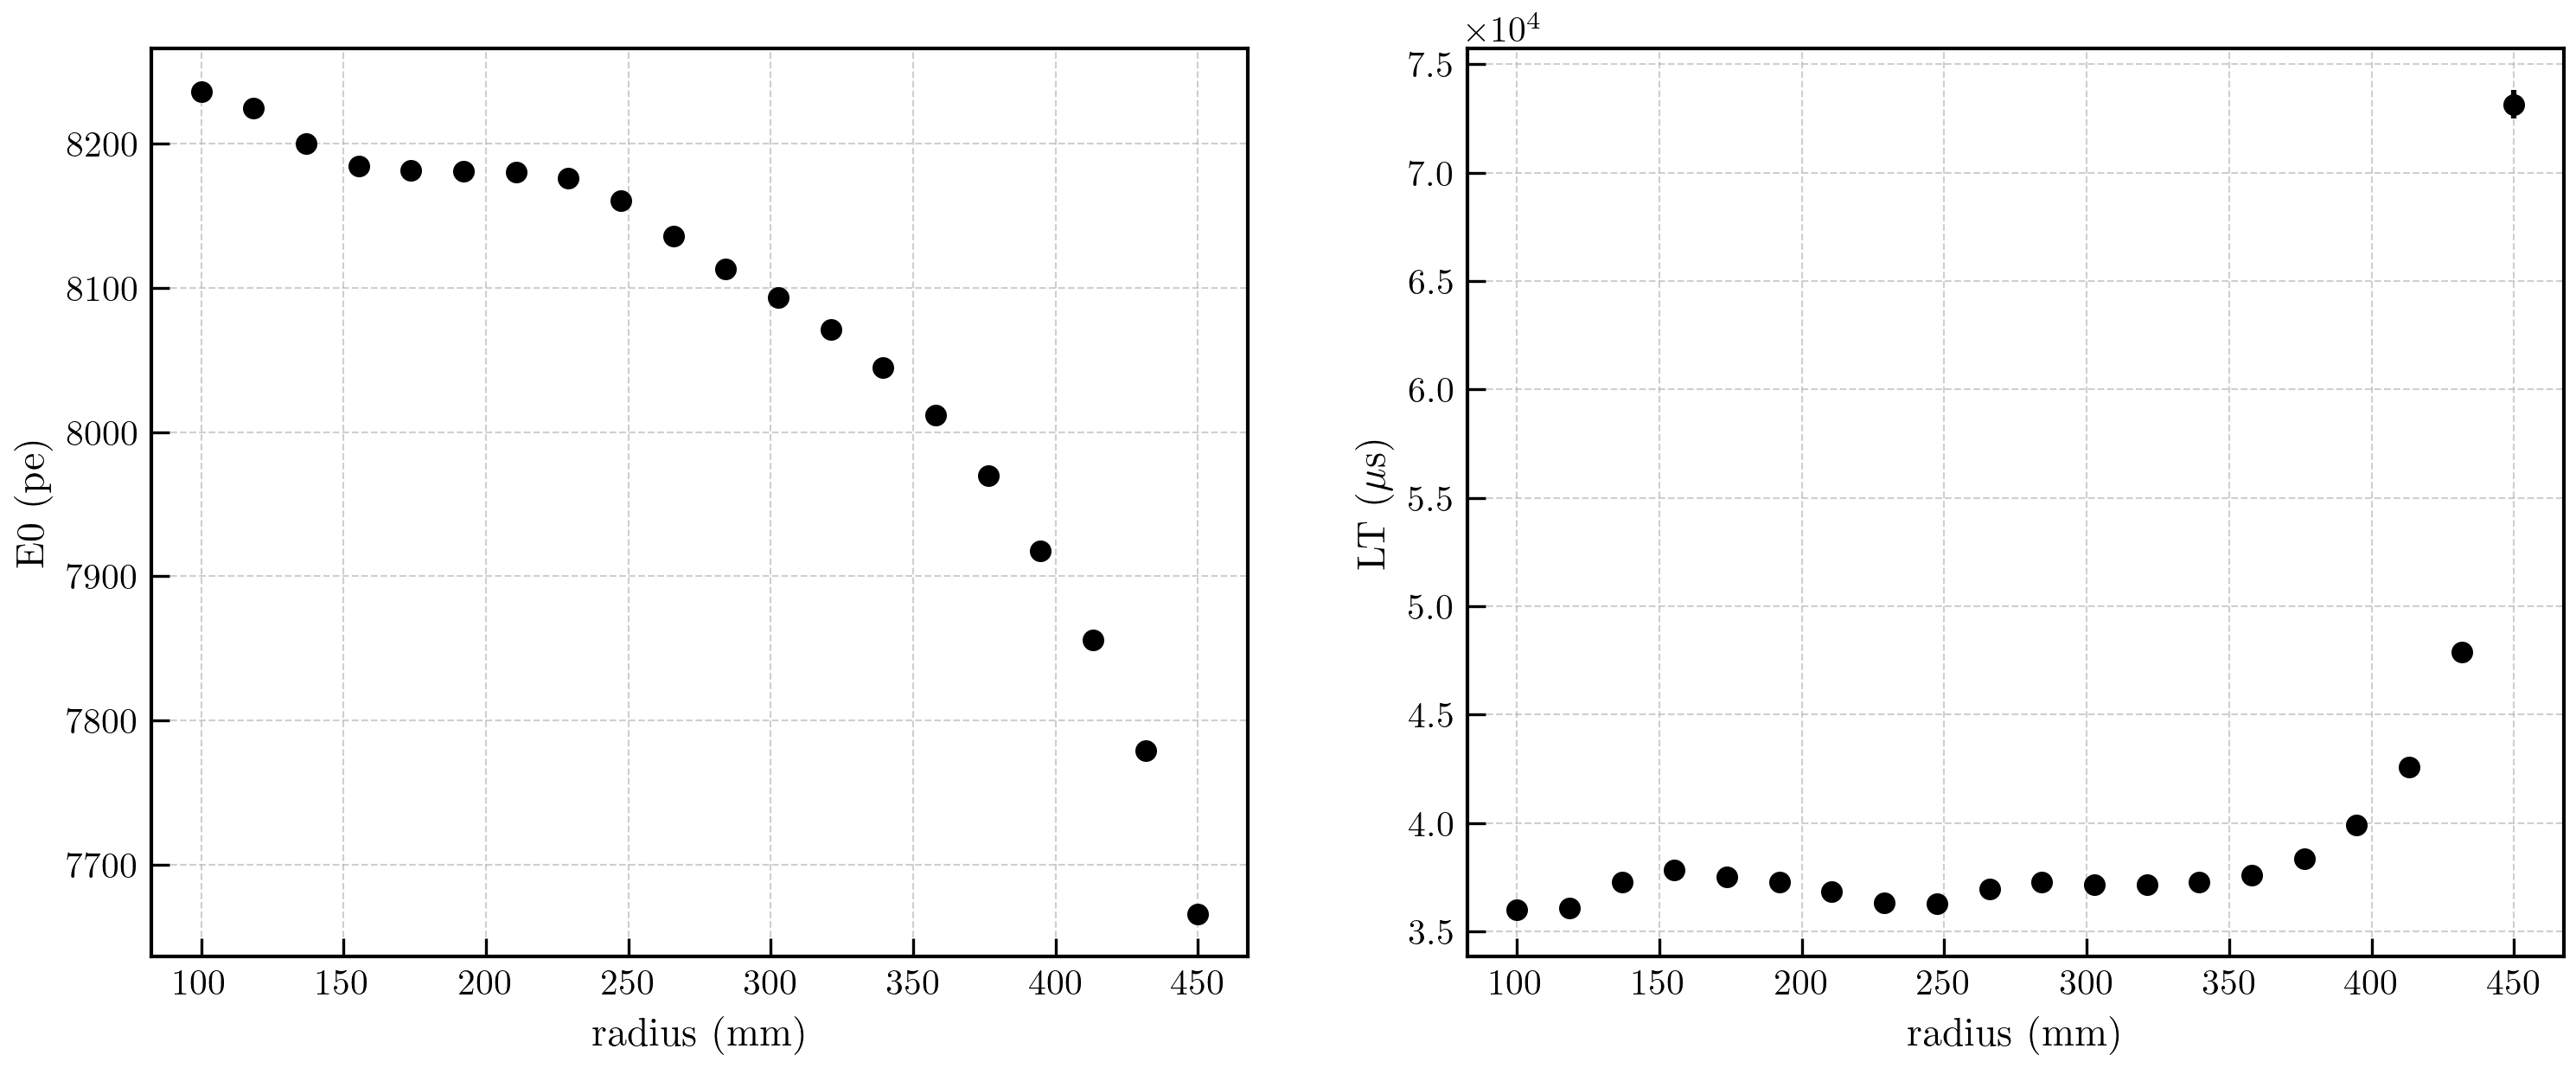

In [137]:
cv = pltext.canvas(4, 2)
cv(1)
plt.errorbar(rs, erefs, yerr = uerefs, fmt='o'); plt.xlabel('radius (mm)'); plt.ylabel('E0 (pe)');
cv(2)
plt.errorbar(rs, lts, yerr = ults, fmt='o'); plt.xlabel('radius (mm)'); plt.ylabel(r'LT ($\mu$s)');

In [139]:
rmax = 350
rsel = r < rmax
cc = lt_unique(dtime[rsel], energy[rsel])
lt = cc[2]
ene = energy * np.exp(dtime/lt)


In [142]:
k2d, res_2  = prof.profile(coors, ene, bins = (68, 68)) 

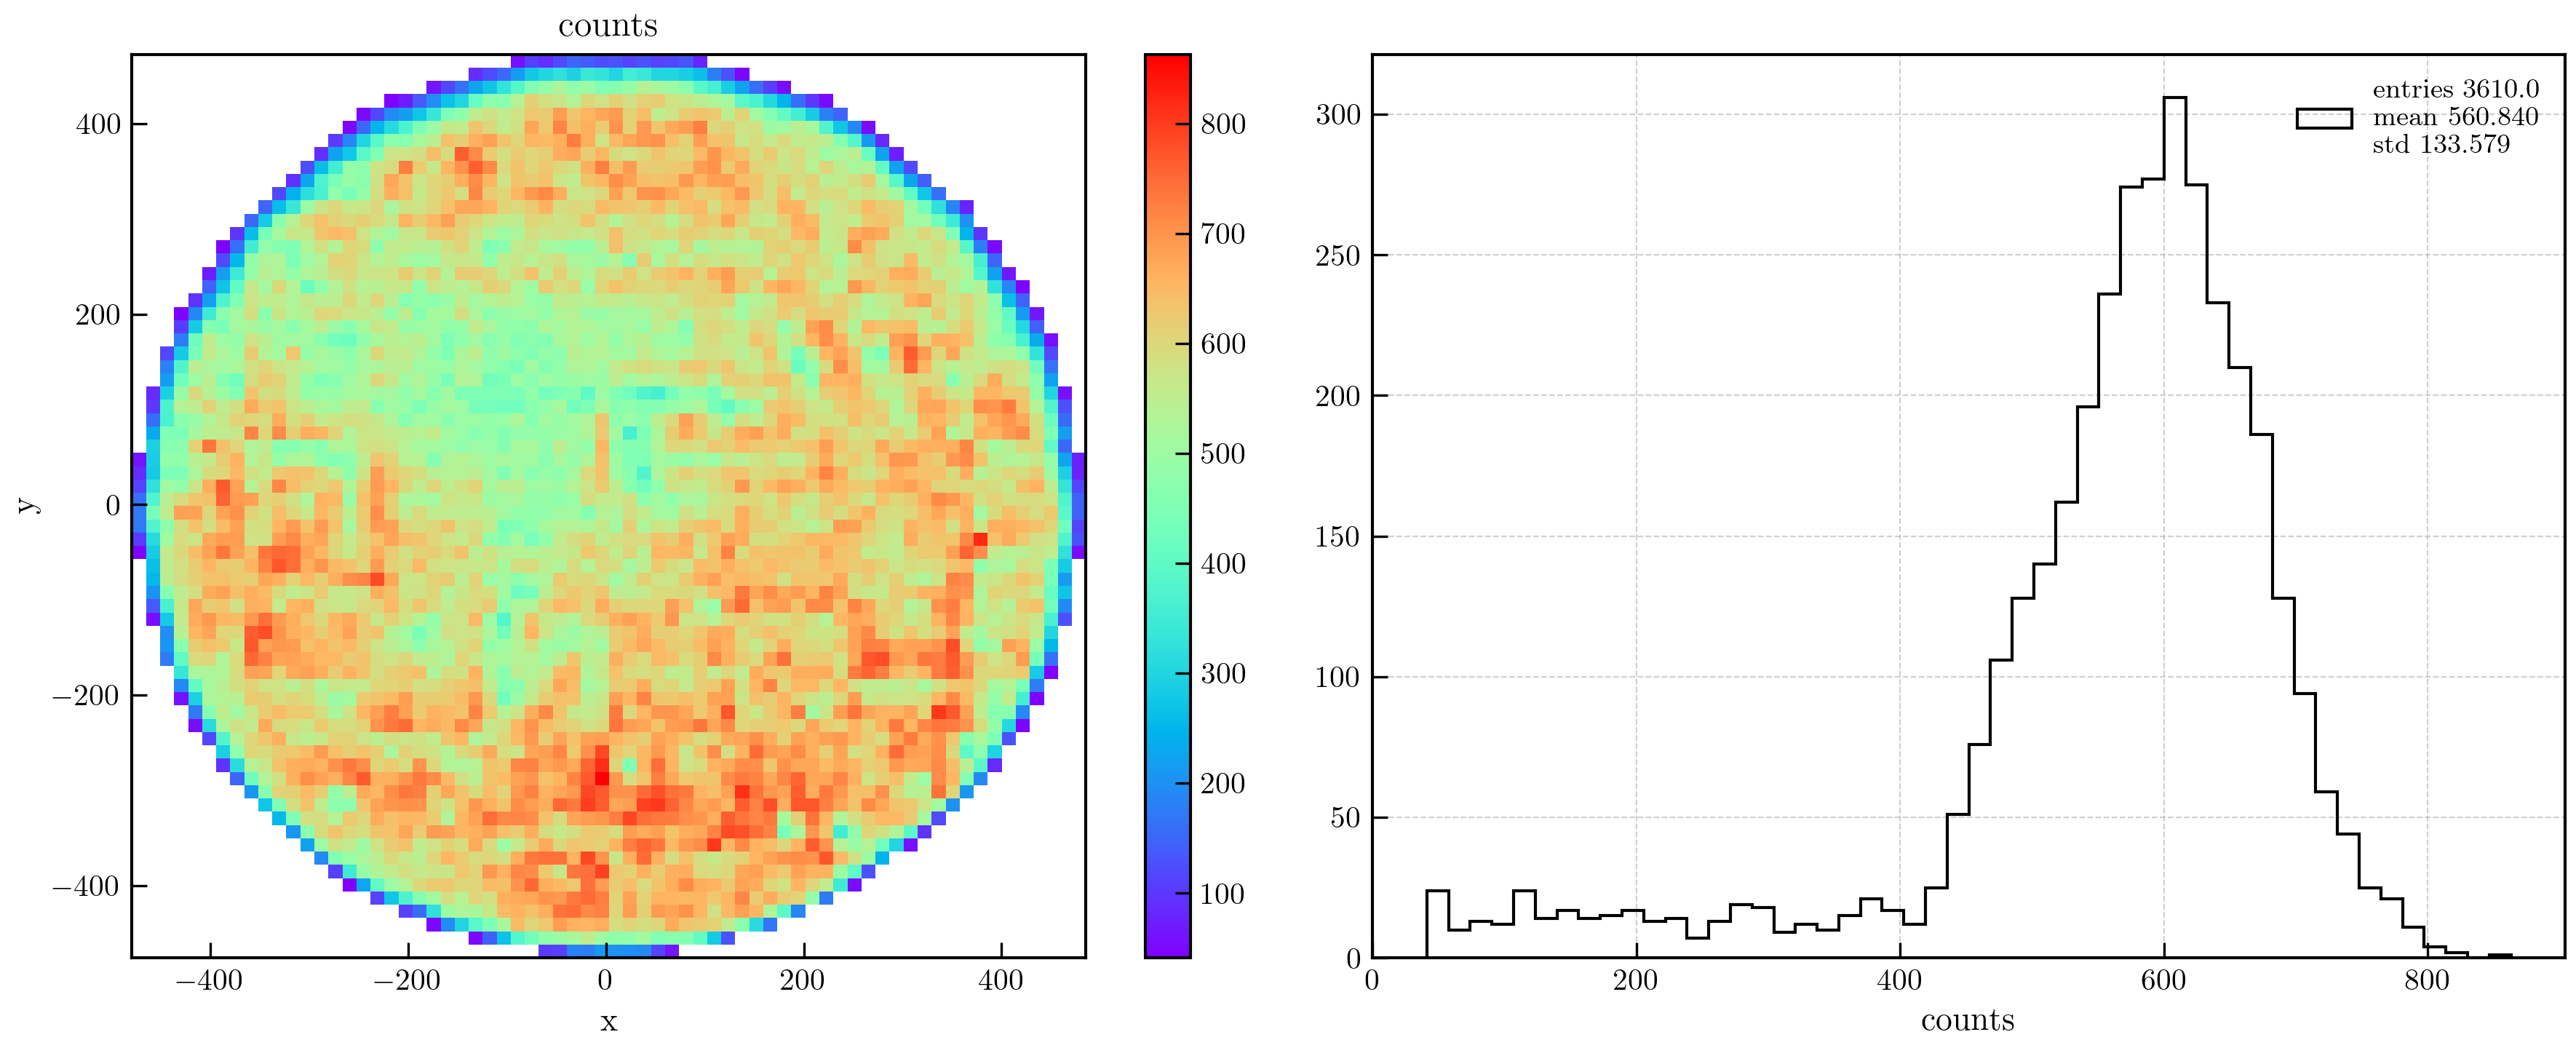

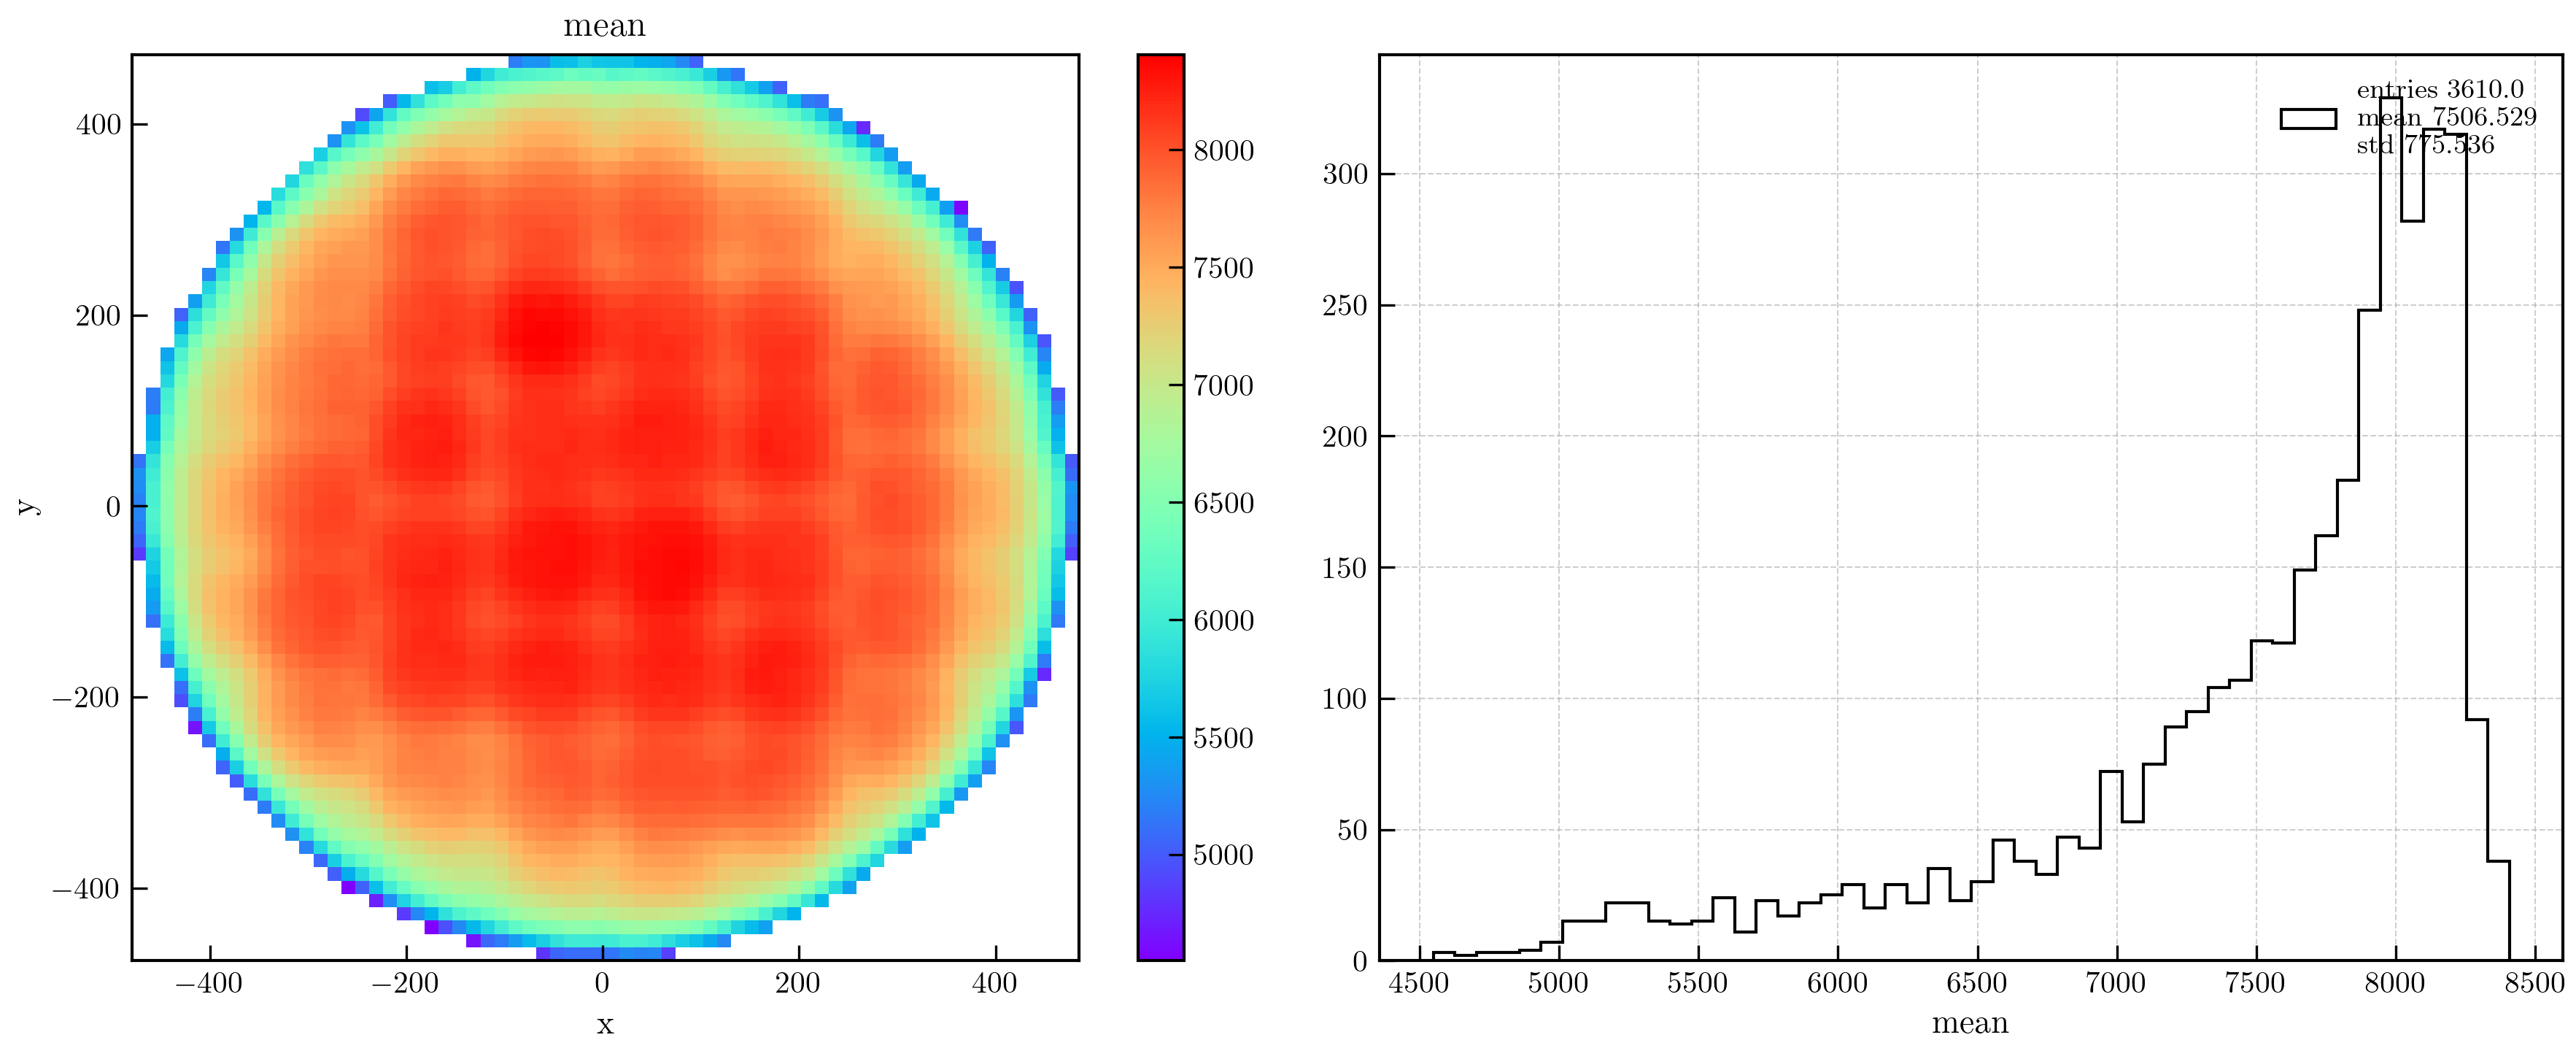

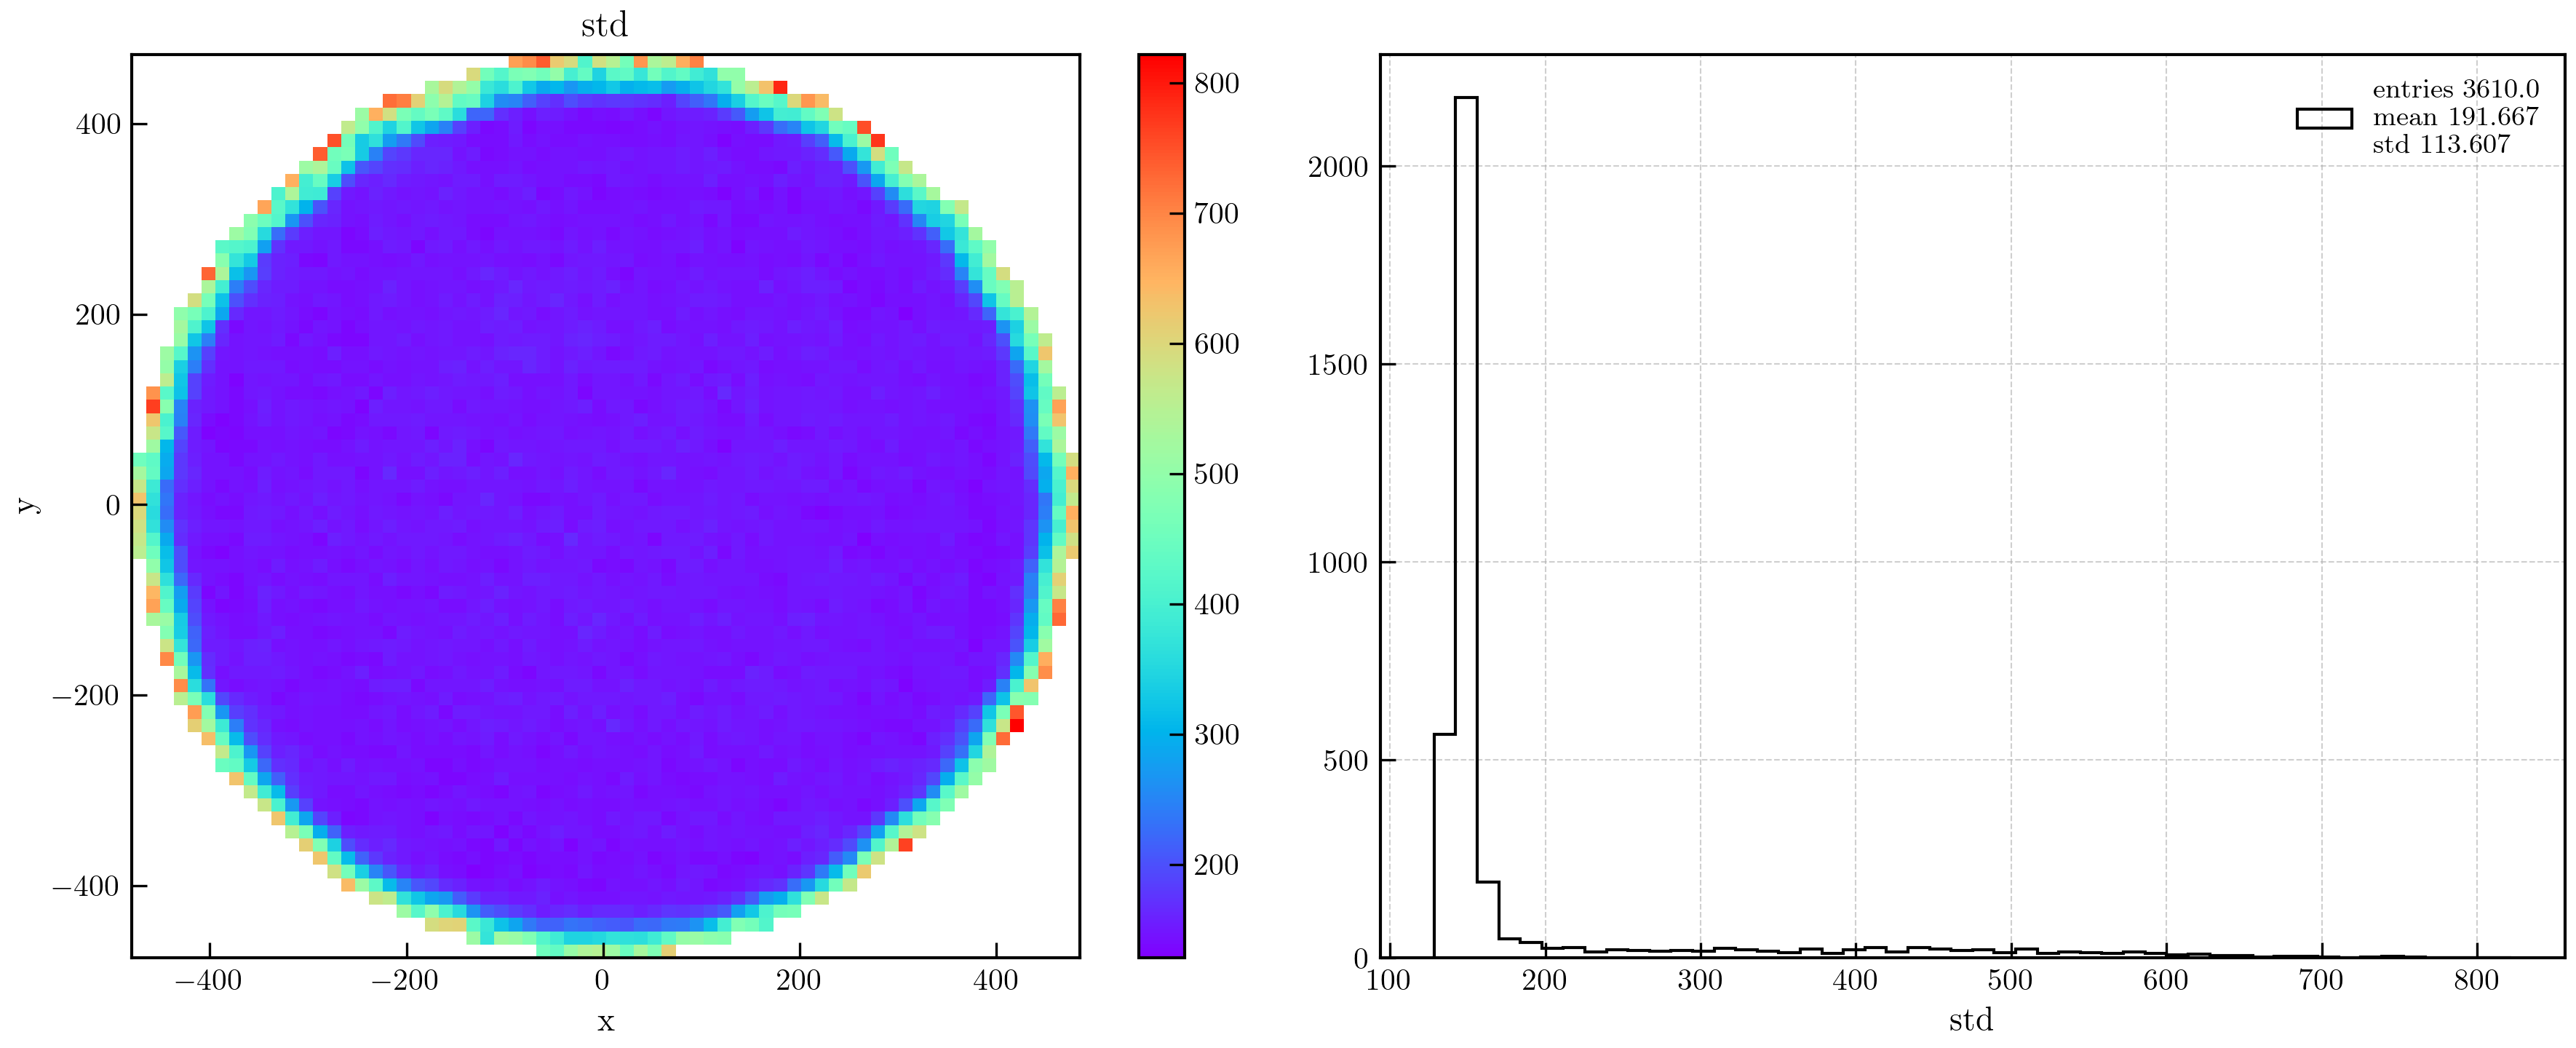

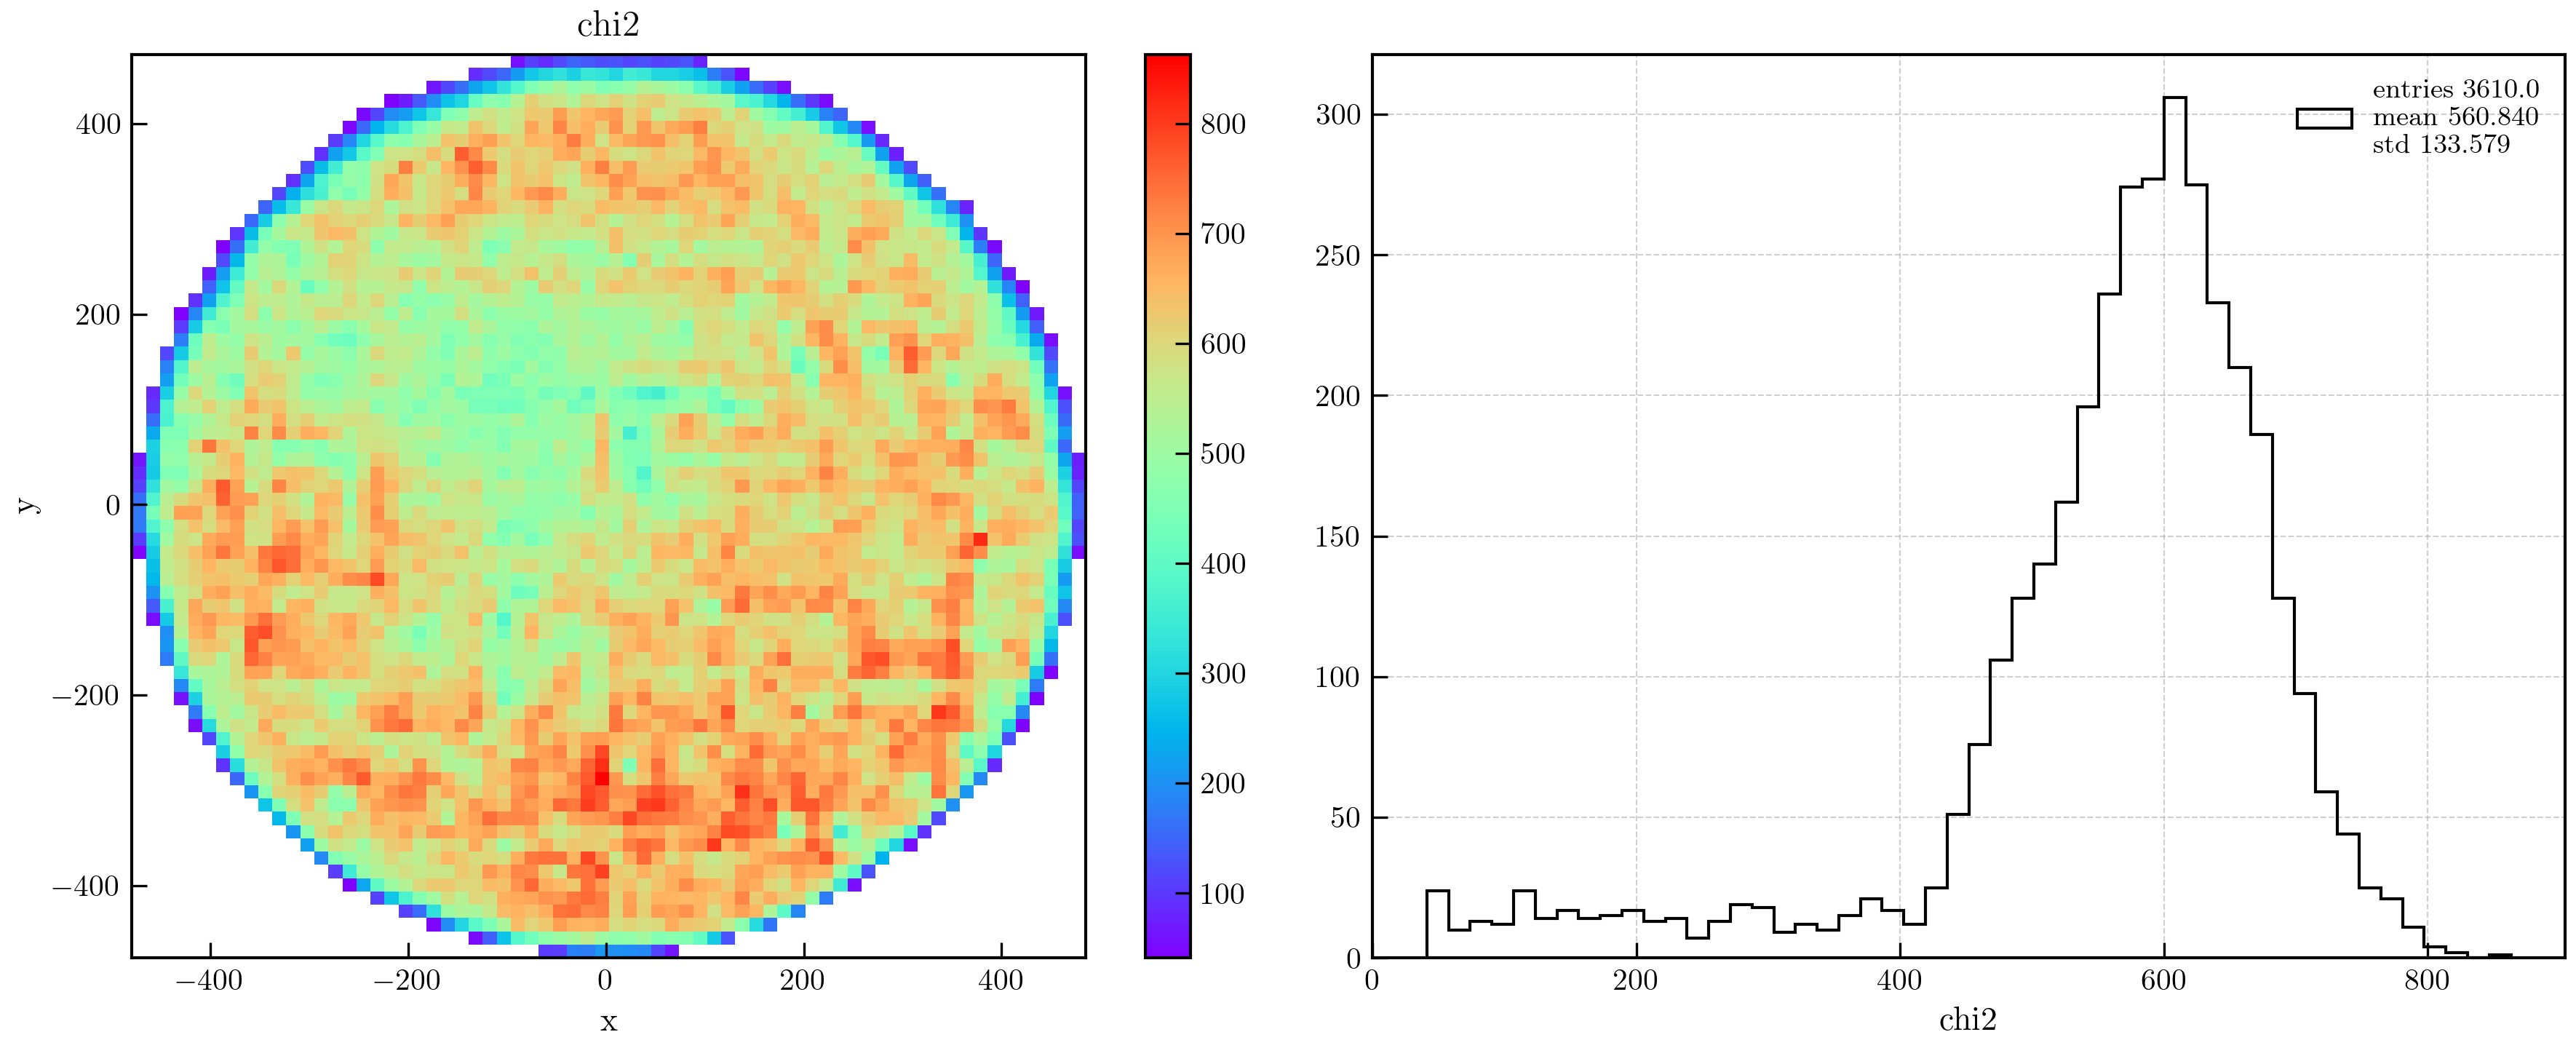

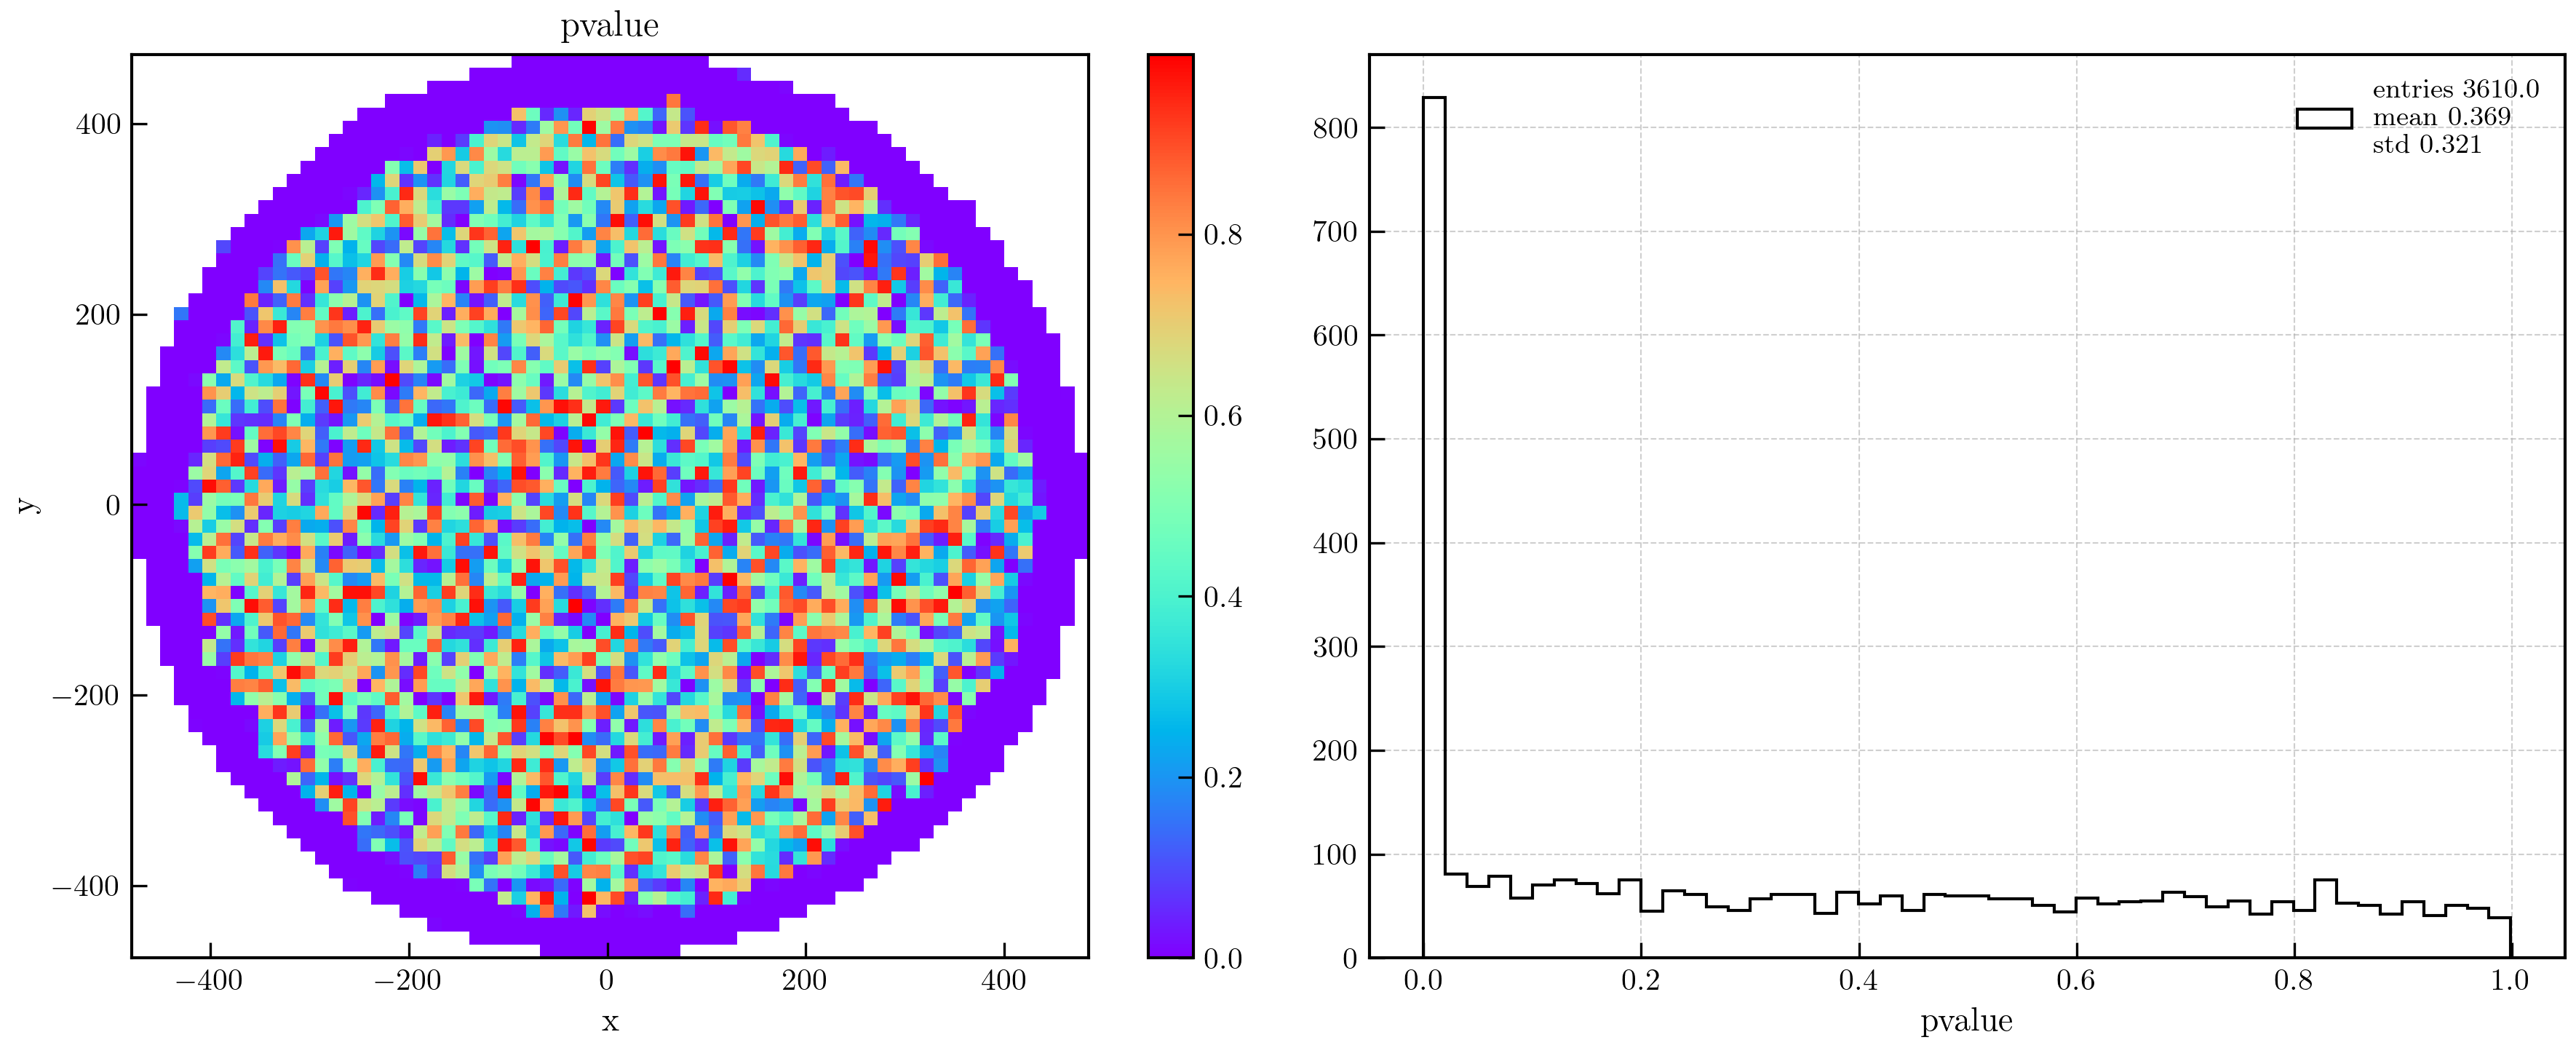

In [144]:
prof.plot_profile(k2d, stats = ('counts', 'mean', 'std', 'chi2', 'pvalue'));

In [145]:
cene_2d = prof.profile_scale((cdf.X, cdf.Y), cdf.S2e * np.exp(cdf.DT/lt), k2d, 41.5)

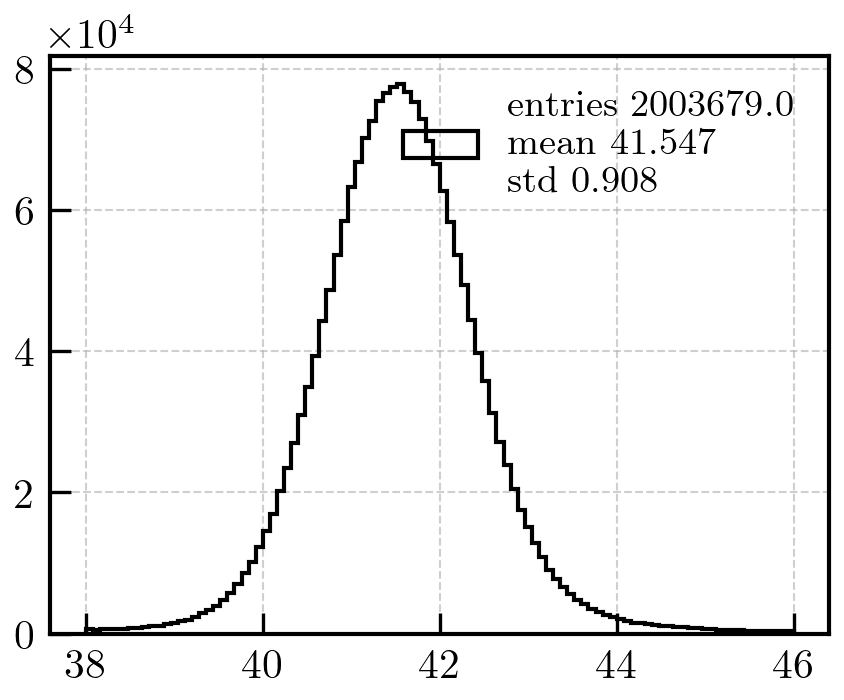

In [147]:
pltext.hist(cene_2d, 100, (38, 46));

In [138]:
print(lts)

[35990.0192514786, 36094.47786299294, 37268.80064655207, 37830.21379201562, 37517.3331658436, 37266.55280651767, 36861.40654839078, 36308.64819865219, 36268.096438976034, 36974.51502682716, 37285.37115699191, 37174.583995804554, 37164.974488068896, 37292.05661286453, 37615.38199457241, 38372.0986164862, 39925.74654364143, 42604.30593891473, 47904.963997295796, 73157.60571246121]


In [154]:
rmax = 350.
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, bins = bins, rmax = rmax)

In [155]:
k2d

KrMapLTU(rmax=350.0, eref=8027.001386947575, ueref=0.4171837941215779, lt=37421.29859934496, ult=99.9520427561913, success=array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]]), prof=Profile(counts=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), mean=array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., 